# Phase 4 - Exploratory Data Analysis

This notebook performs basic inspection and data quality analysis of the Phase-3 feature-engineered datasets without altering them.

## 1. Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure src/ is in the python path to import eda module
sys.path.append(os.path.abspath('..'))

import pandas as pd
from src.eda import (
    load_feature_engineered_data,
    get_dataset_overview,
    get_date_info,
    analyze_zero_volume,
    check_chronological_order,
    validate_missing_values,
    get_numerical_sanity_check,
    identify_outliers_iqr
)

# Set display options for better inspection
pd.set_option('display.max_columns', None)

In [3]:
import src.eda as eda
import inspect

print("Loaded eda.py from:")
print(eda.__file__)

print("\n200 test:")
print('200' in 'NIFTY50_Market_Trend_200D')

print("\nLoaded function:")
print(inspect.getsource(eda.validate_missing_values))

Loaded eda.py from:
c:\Users\vighn\OneDrive\Desktop\sector rotation regime discovery\src\eda.py

200 test:
True

Loaded function:
def validate_missing_values(datasets: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Compares actual missing values against expected rolling-window missing values.
    """
    results = []
    for name, df in datasets.items():
        missing = df.isnull().sum()
        missing = missing[missing > 0]
        for feature, count in missing.items():
            expected = 0
            if '200' in feature:
                expected = 200
            elif '60' in feature:
                expected = 60
            elif '20' in feature:
                expected = 20
            elif '14' in feature:
                expected = 14
            elif '10' in feature:
                expected = 10
            elif '5' in feature:
                expected = 5
                
            # Using exact match or close (rolling windows sometimes yield N-1 NaNs)
      

## 2. Load Feature-Engineered Datasets

Load all seven final Phase-3 CSV files individually. We explicitly parse the `Date` column as `datetime64[ns]`.

In [4]:
data_dir = '../data/processed/feature_engineered/'
datasets = load_feature_engineered_data(data_dir)

print(f"Successfully loaded {len(datasets)} datasets:")
for name in datasets.keys():
    print(f"- {name}")

Successfully loaded 7 datasets:
- NIFTY 50
- NIFTY Auto
- NIFTY Bank
- NIFTY FMCG
- NIFTY IT
- NIFTY Metal
- NIFTY Pharma


# 3. Data Quality Analysis

In this section, we verify the data quality using zero-volume checks, chronological ordering checks, missing-value validation, sanity checks, and statistical outlier quantification. Data remains unmodified.

### 3.1 Zero-Volume Analysis
Quantify the number and percentage of zero-volume observations.

In [5]:
zero_volume_summary = analyze_zero_volume(datasets)
display(zero_volume_summary)

,Dataset,Total Rows,Zero Volume Count,Zero Volume %,Non-Zero Volume Count
0,NIFTY 50,1886,13,0.69,1873
1,NIFTY Auto,1886,0,0.00,1886
2,NIFTY Bank,1886,420,22.27,1466
3,NIFTY FMCG,1886,0,0.00,1886
4,NIFTY IT,1886,424,22.48,1462
5,NIFTY Metal,1886,0,0.00,1886
6,NIFTY Pharma,1886,1,0.05,1885


### 3.2 Chronological Order Check
Verify whether the `Date` column is monotonically increasing for each dataset.

In [6]:
#It checks whether the Date column in each dataset is arranged from oldest → newest without going backward.
chronological_summary = check_chronological_order(datasets)
display(chronological_summary)

,Dataset,Dates Monotonically Increasing
0,NIFTY 50,True
1,NIFTY Auto,True
2,NIFTY Bank,True
3,NIFTY FMCG,True
4,NIFTY IT,True
5,NIFTY Metal,True
6,NIFTY Pharma,True


### 3.3 Missing-Value Validation
Compare actual missing values against expected rolling-window missing values (e.g., 20 observations missing for a 20D feature).

In [7]:
missing_value_summary = validate_missing_values(datasets)
display(missing_value_summary)

,Dataset,Feature,Missing Count,Expected Count,Status
0,NIFTY 50,Return_20D,20,20,Expected
1,NIFTY 50,Return_60D,60,60,Expected
2,NIFTY 50,NIFTY50_Momentum_20D,19,20,Expected
3,NIFTY 50,NIFTY50_Momentum_60D,59,60,Expected
4,NIFTY 50,Volatility_20D,20,20,Expected
5,NIFTY 50,NIFTY50_Market_Trend_200D,199,200,Expected
6,NIFTY Auto,Return_20D,20,20,Expected
7,NIFTY Auto,Return_60D,60,60,Expected
8,NIFTY Auto,Relative_Strength_20D,20,20,Expected
9,NIFTY Auto,Relative_Strength_60D,60,60,Expected


### 3.4 Numerical Feature Sanity Check
Inspect the minimum, maximum, mean, median, and standard deviation for numerical engineered features.

In [8]:
sanity_check_summary = get_numerical_sanity_check(datasets)
display(sanity_check_summary)

,Dataset,Feature,Min,Max,Mean,Median,Std Dev
0,NIFTY 50,Adj Close,7610.250000,26328.550781,18187.899350,17855.799805,5174.311001
1,NIFTY 50,Close,7610.250000,26328.550781,18187.899350,17855.799805,5174.311001
2,NIFTY 50,High,8036.950195,26373.199219,18282.184641,17945.700195,5185.083294
3,NIFTY 50,Low,7511.100098,26210.050781,18089.388382,17779.650391,5164.341944
4,NIFTY 50,Open,7735.149902,26333.699219,18197.679057,17881.349609,5172.772279
...,...,...,...,...,...,...,...
79,NIFTY Pharma,Return_60D,-0.203312,0.610746,0.040198,0.025106,0.095391
80,NIFTY Pharma,Relative_Strength_20D,-0.139998,0.371269,0.003657,-0.000616,0.054320
81,NIFTY Pharma,Relative_Strength_60D,-0.181671,0.425785,0.010023,-0.003086,0.096404
82,NIFTY Pharma,Volatility_20D,0.072483,0.730471,0.170715,0.157837,0.075281


### 3.5 Potential Outlier Identification
Use the IQR rule (Q1 - 1.5*IQR to Q3 + 1.5*IQR) to quantify potential statistical outliers.

In [9]:
outliers_summary = identify_outliers_iqr(datasets)
display(outliers_summary)

,Dataset,Feature,Potential Outlier Count
0,NIFTY 50,Volume,55
1,NIFTY 50,Return_20D,49
2,NIFTY 50,Return_60D,70
3,NIFTY 50,NIFTY50_Momentum_20D,44
4,NIFTY 50,NIFTY50_Momentum_60D,33
5,NIFTY 50,Volatility_20D,100
6,NIFTY 50,NIFTY50_Market_Trend_200D,94
7,NIFTY Auto,Volume,116
8,NIFTY Auto,Return_20D,61
9,NIFTY Auto,Return_60D,57


### Conclusion of Data Quality Analysis
- Validated all 7 datasets structure, chronological order, and expected missing values.
- No files were modified, and datasets were kept completely intact.
- No visual EDA (plots) or data modifications have been executed yet.

## 4 VISUAL EDA
IN this section we will analyze the feature data by plotting and analyzing diff distibutions , correlations and based on that decide what features should be kept and what should be not 

## 4.1 Feature Distribution Analysis

This section analyzes the distributions of the engineered numerical features across the seven datasets to understand their shape, skewness, spread, concentration, and extreme values.

It also helps identify whether the same feature behaves differently across sectors.

`Volume` is included under investigation because previous EDA identified unreliable zero-volume observations in some index datasets.

**Note:** No data is modified, capped, removed, or transformed in this step. NaN values are ignored only for plotting.

Final feature-selection decisions will be made after the relevant EDA analyses are completed.

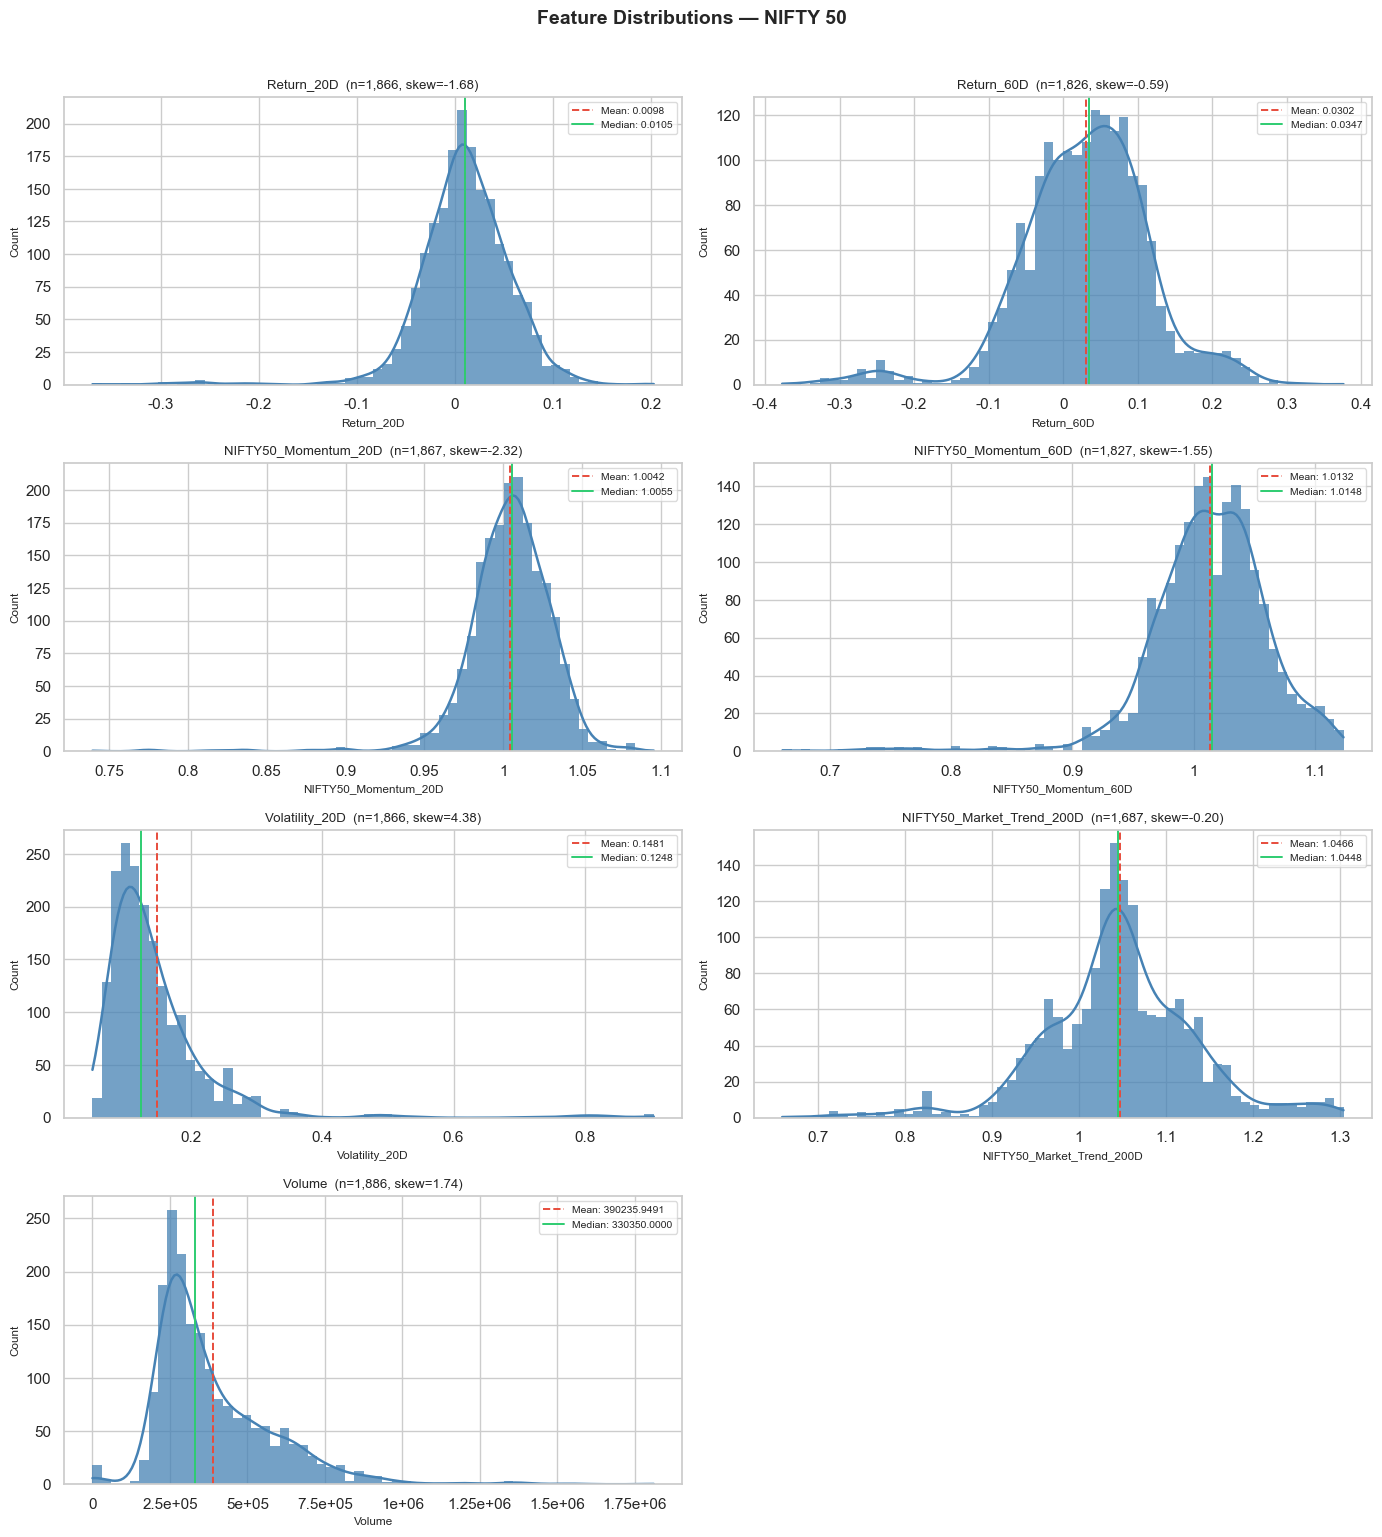

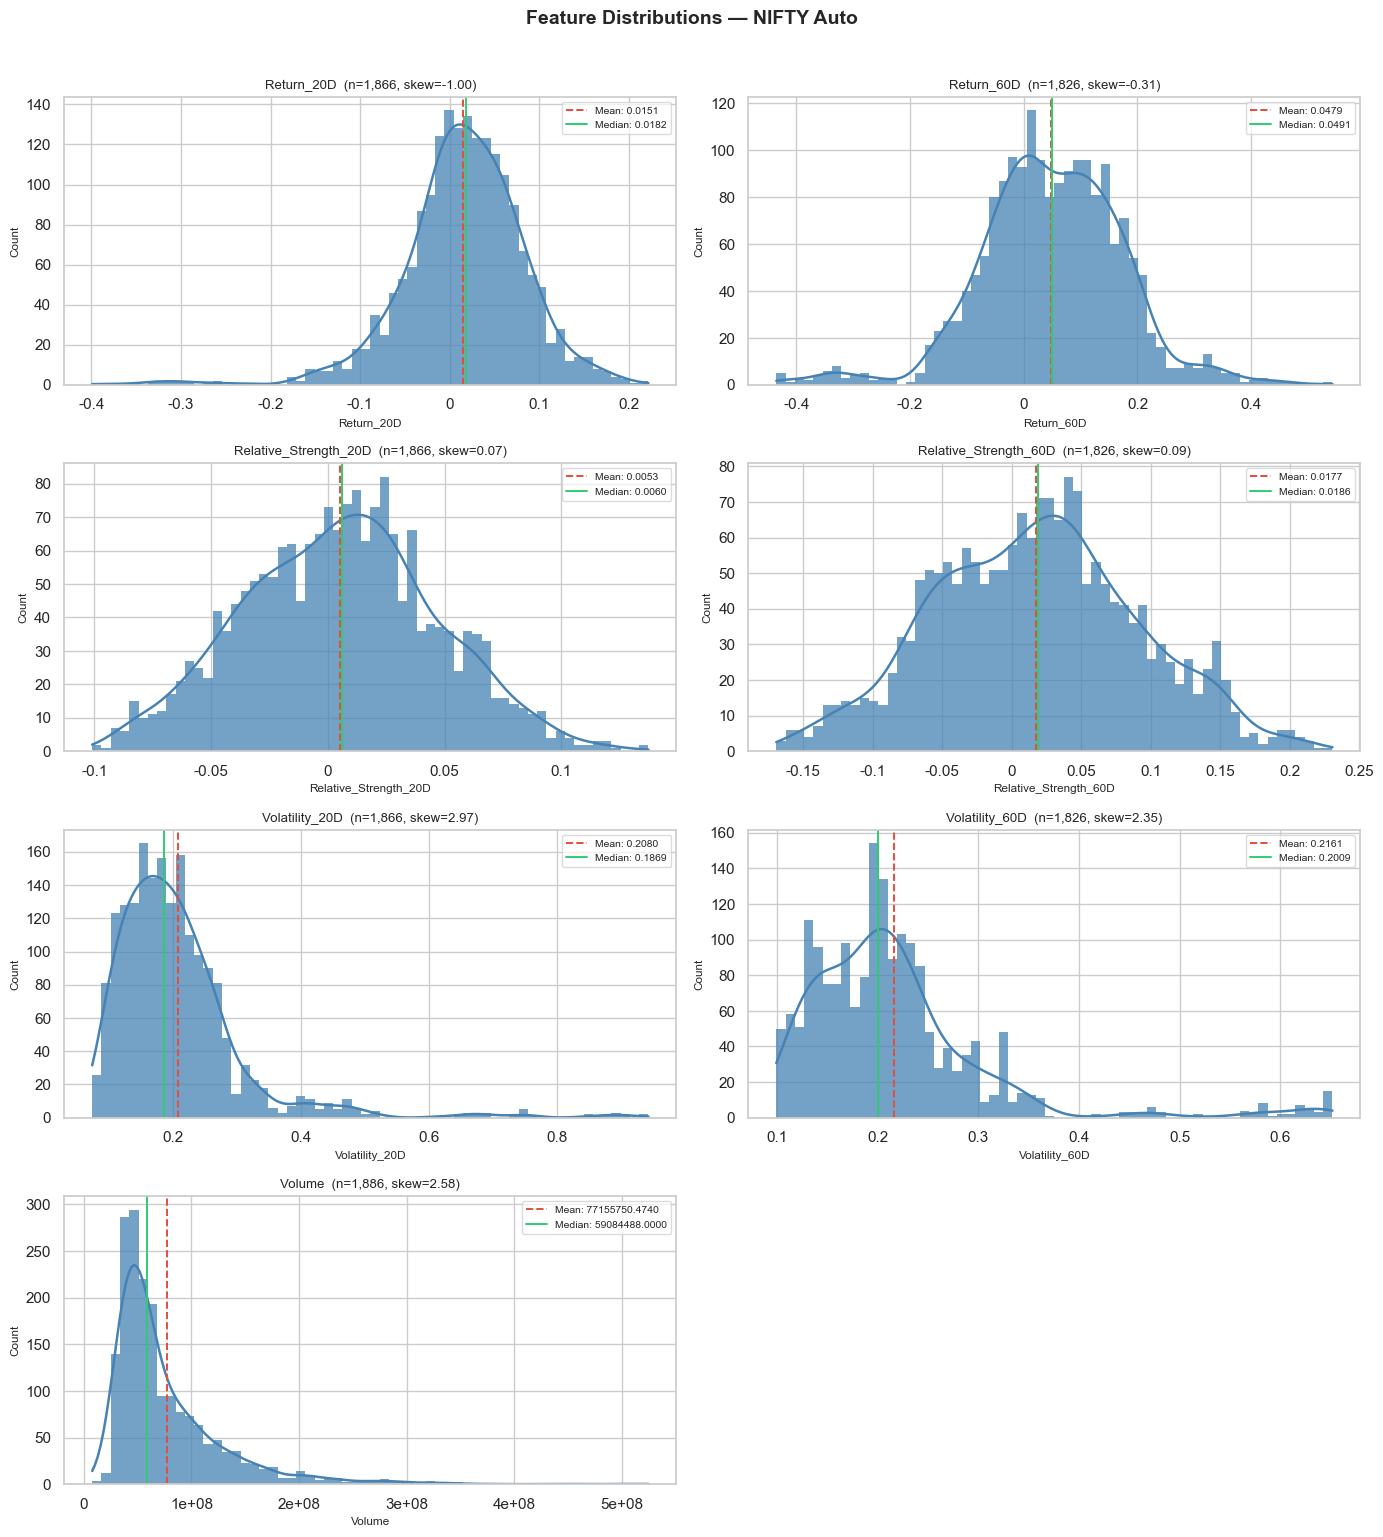

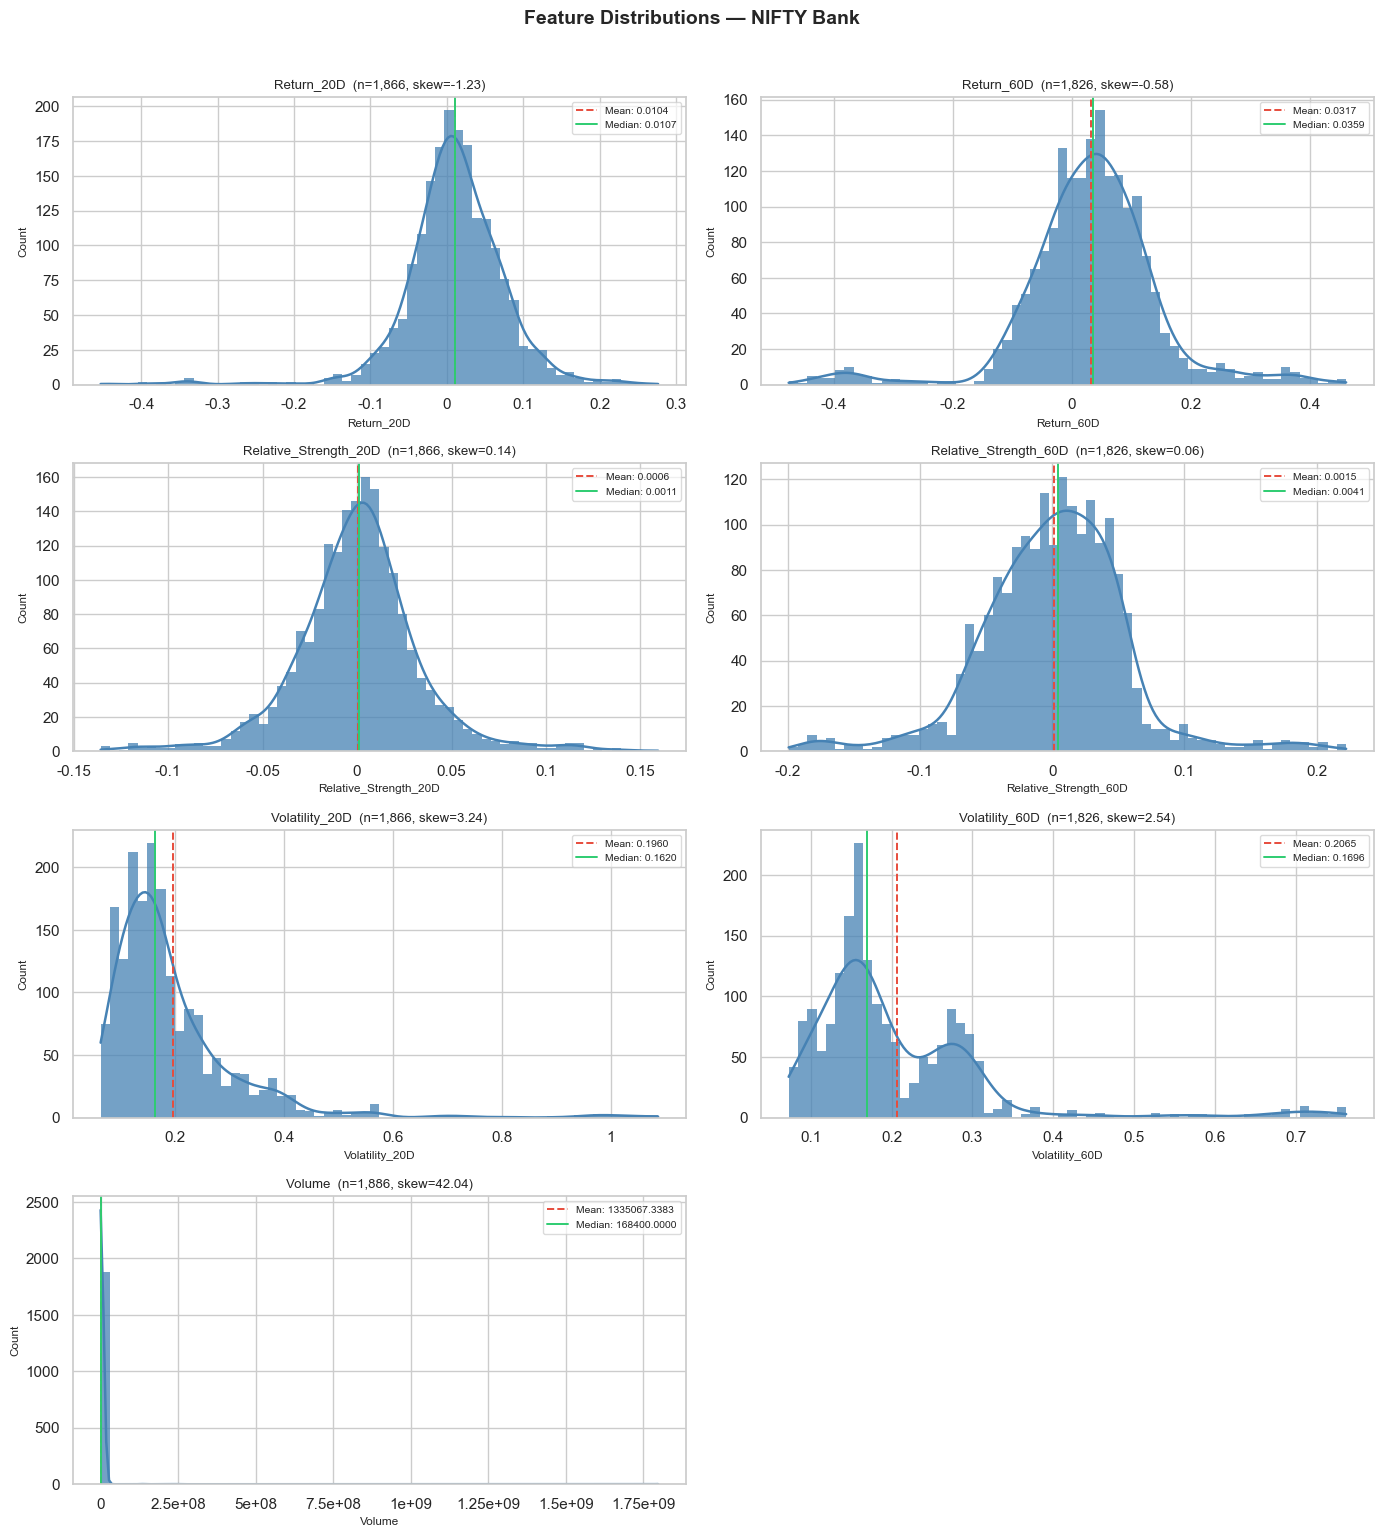

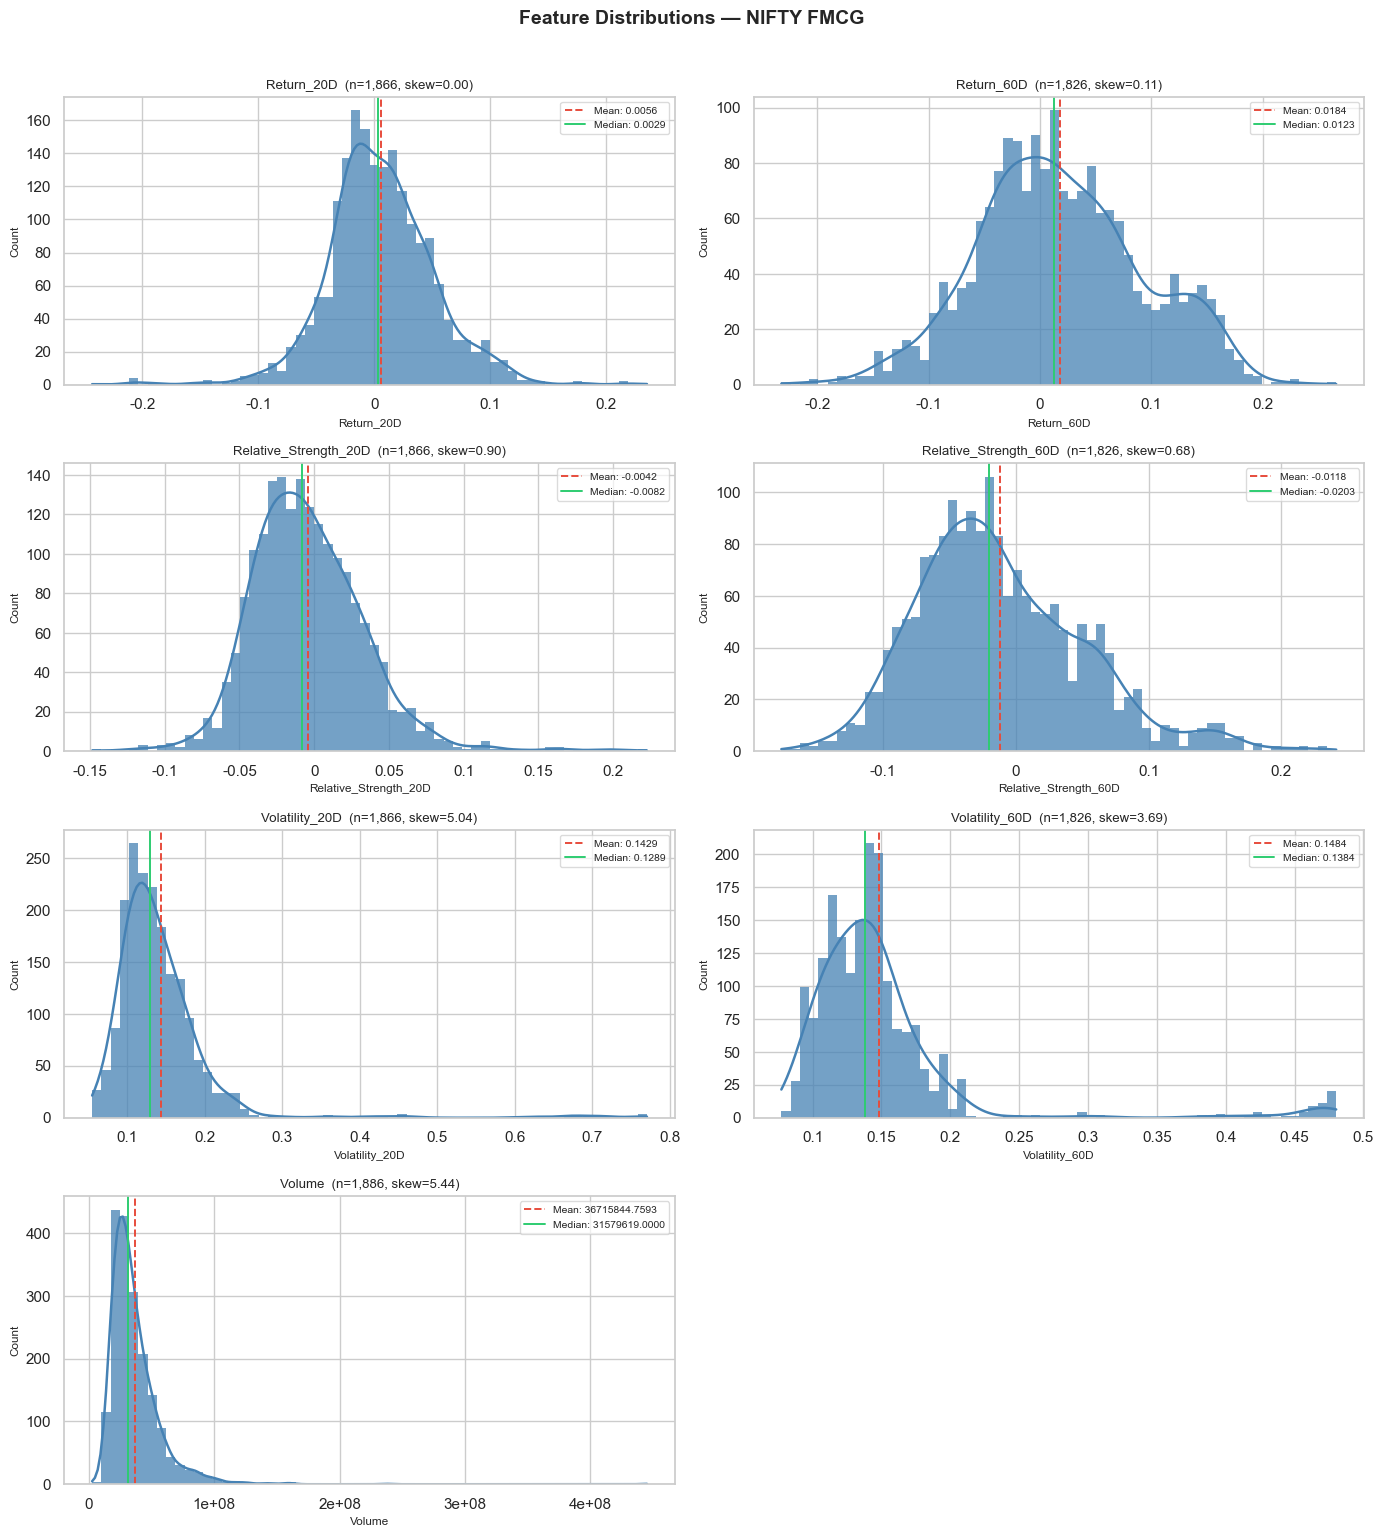

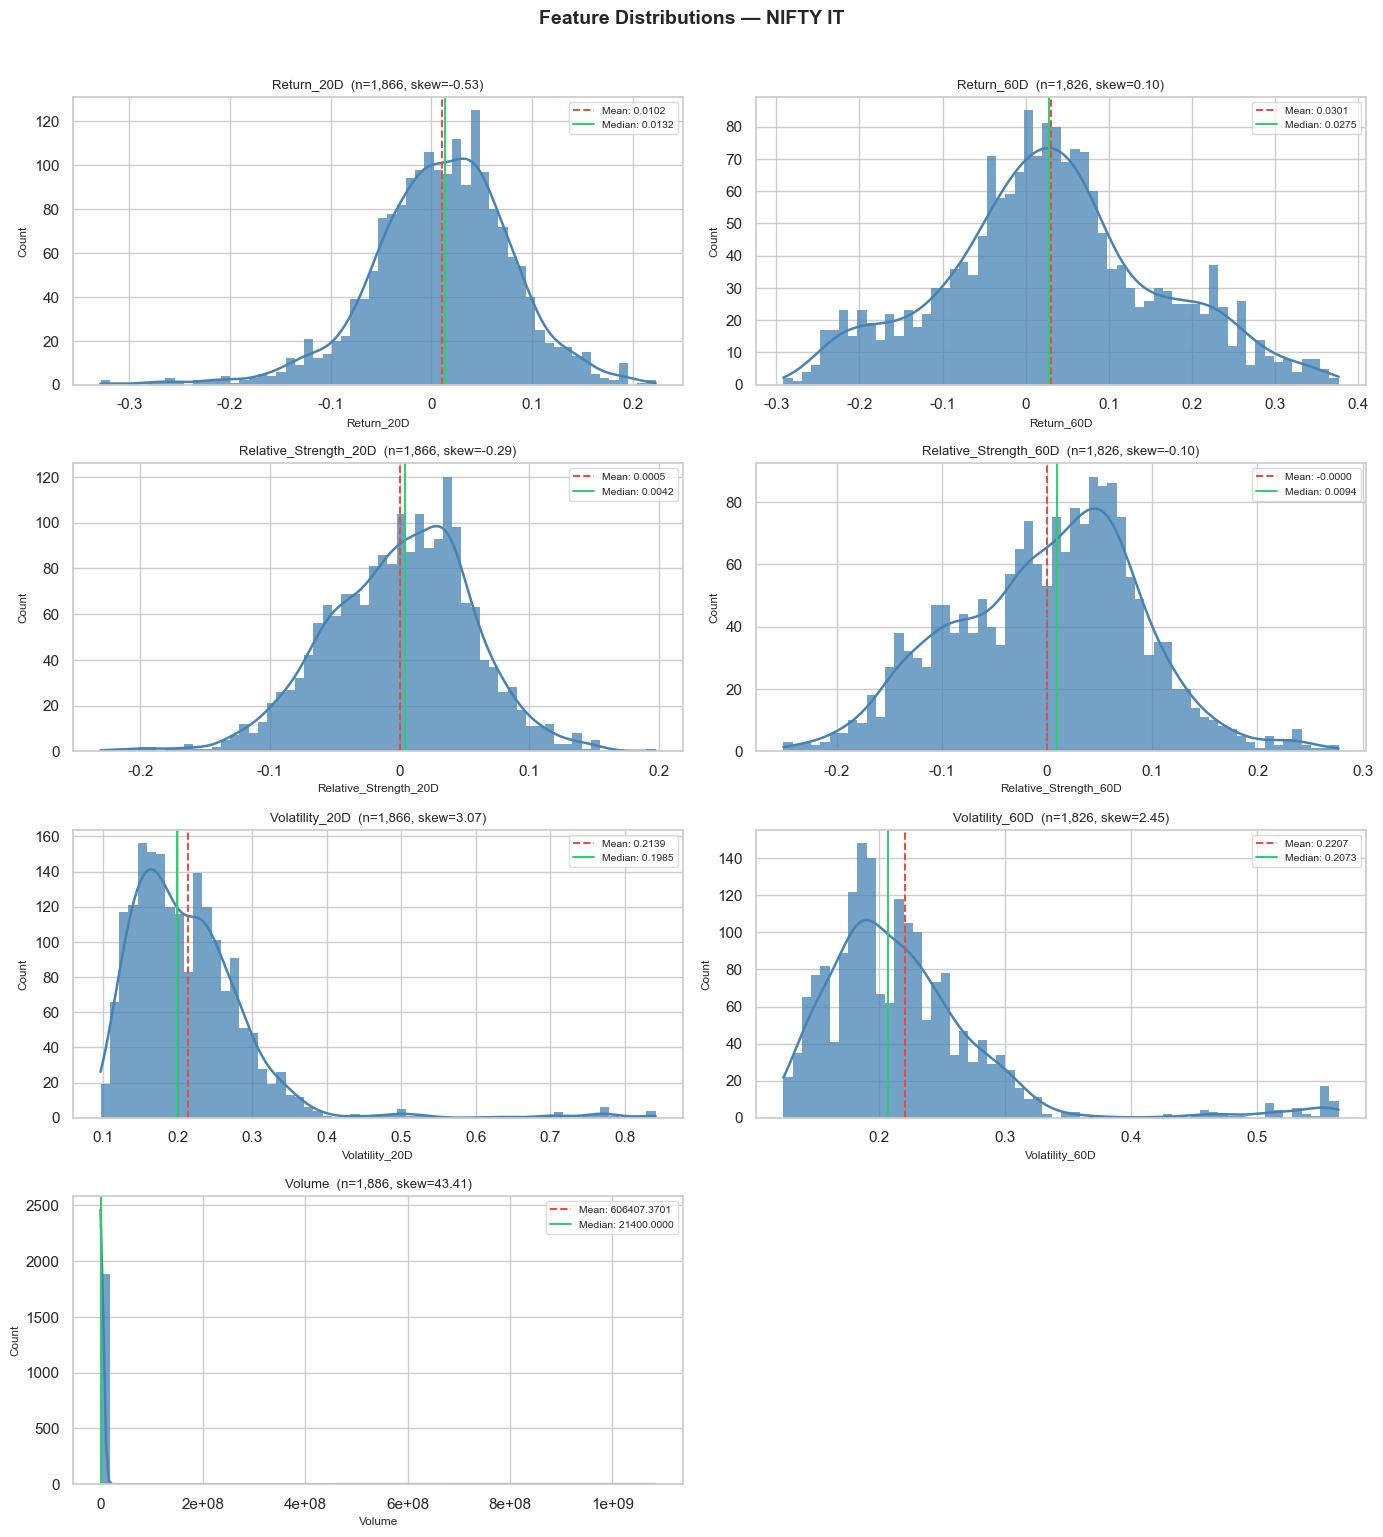

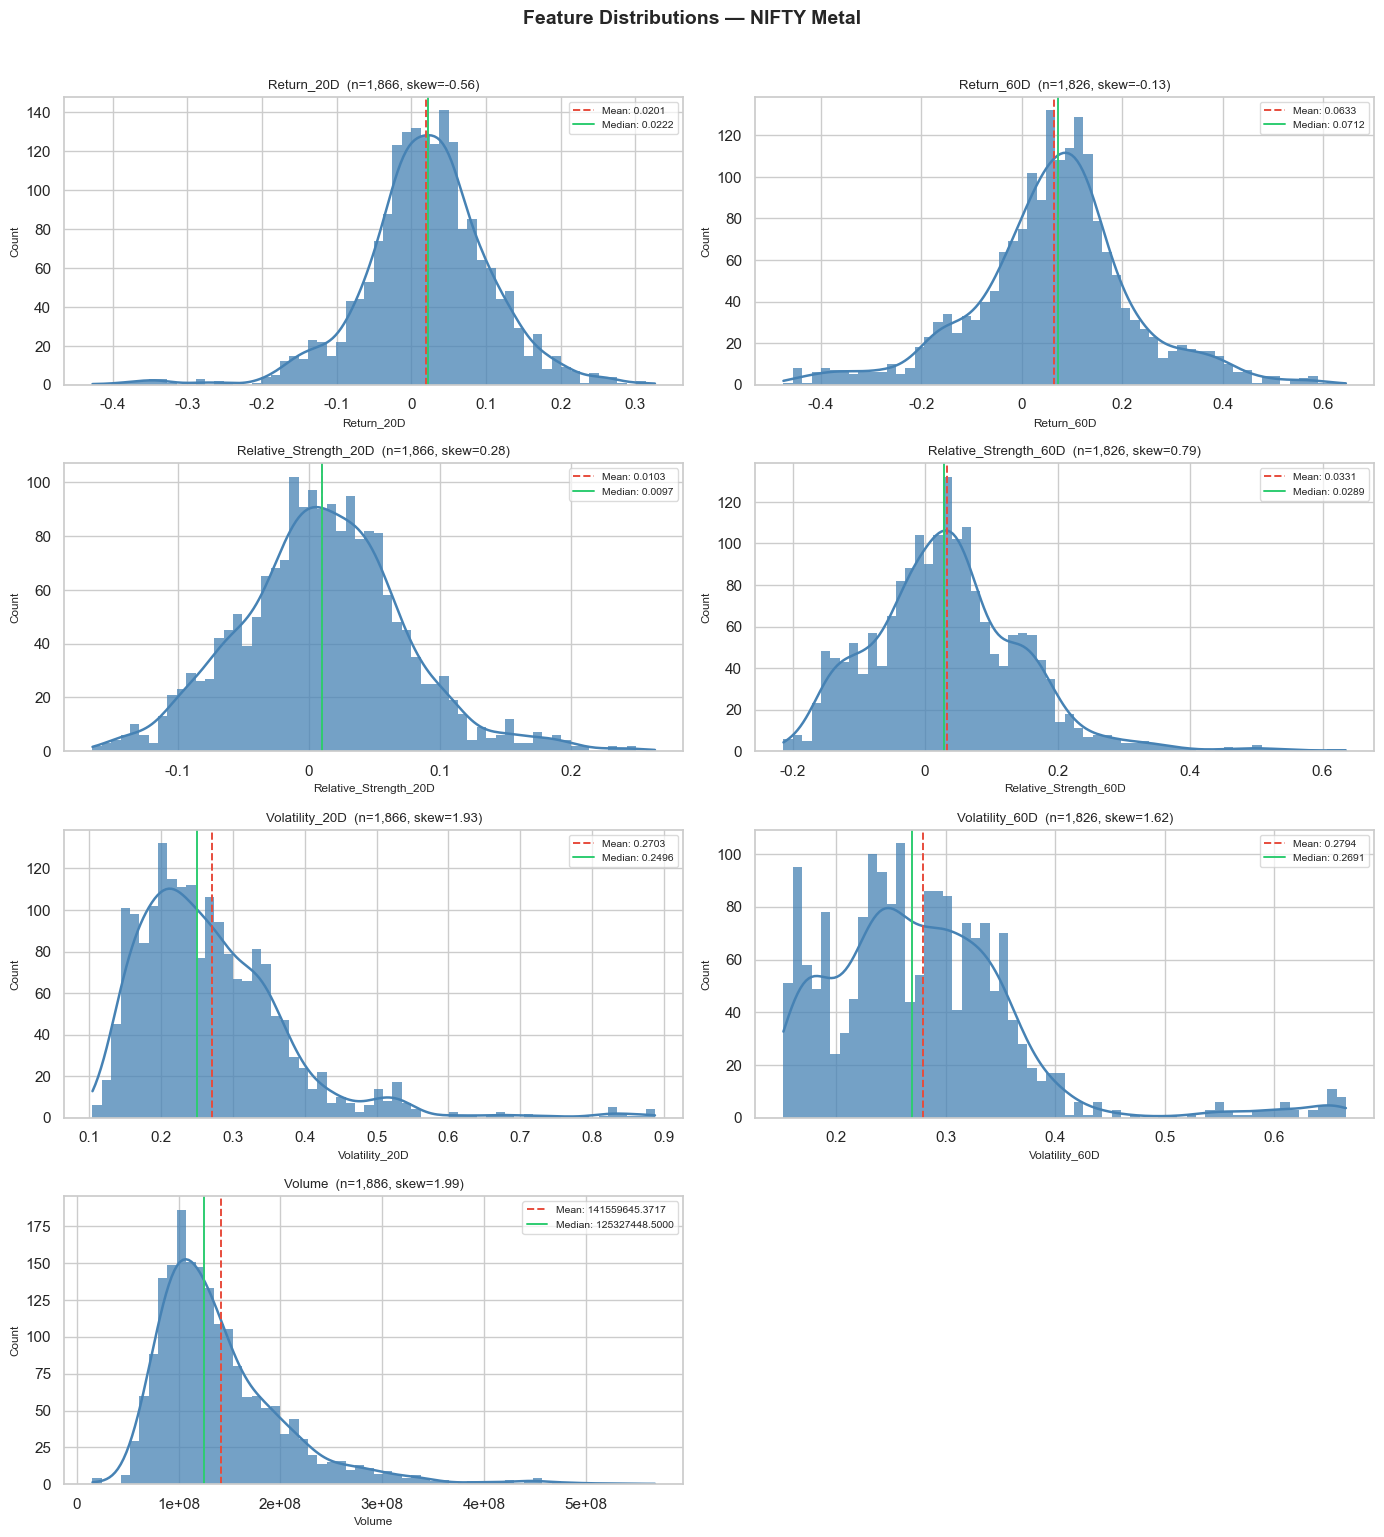

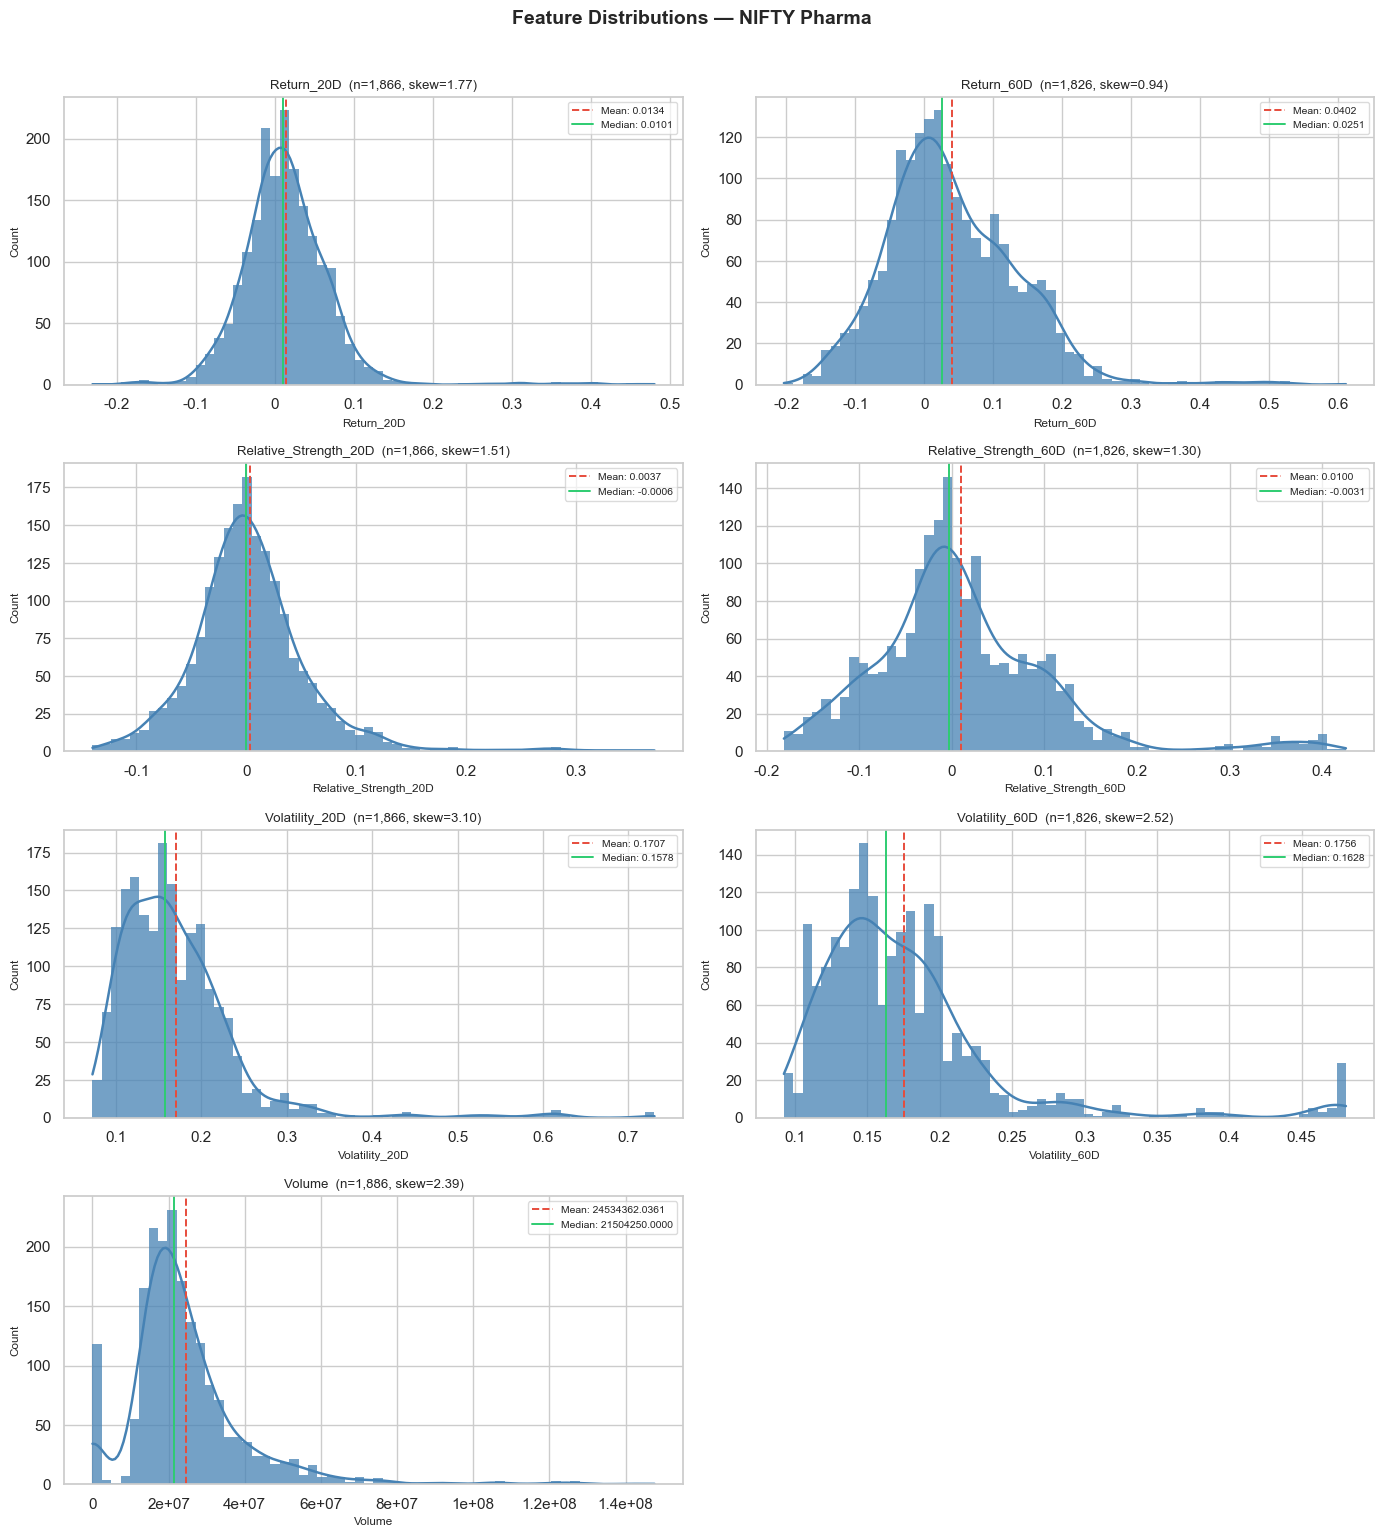

In [10]:
from src.eda import plot_feature_distributions

features_to_plot = {
    "NIFTY 50": [
        "Return_20D",
        "Return_60D",
        "NIFTY50_Momentum_20D",
        "NIFTY50_Momentum_60D",
        "Volatility_20D",
        "NIFTY50_Market_Trend_200D",
        "Volume",
    ],
    
    "default": [
        "Return_20D",
        "Return_60D",
        "Relative_Strength_20D",
        "Relative_Strength_60D",
        "Volatility_20D",
        "Volatility_60D",
        "Volume",
    ],
}

plot_feature_distributions(datasets, features_to_plot)

## infer from 4.1
The feature distributions show several characteristic properties of financial-market data. Return features generally exhibit negative skewness, while volatility and volume features are positively skewed with relatively long right tails. Shorter-horizon features tend to show stronger asymmetry than their longer-horizon counterparts. Relative-strength features are comparatively well behaved and generally exhibit distributions closer to symmetry across sectors. NIFTY 50 momentum features show negative skewness, while the 200-day market-trend feature is comparatively balanced.

These observations indicate that the engineered features contain non-normal and asymmetric distributions, which is expected in financial data and does not by itself indicate poor-quality features. In particular, the right-skewed volatility distributions may capture periods of elevated market stress that could be relevant for regime discovery. Volume requires additional investigation because its distribution is highly skewed and earlier data-quality analysis identified zero-volume observations in some datasets.

No features are removed or transformed based solely on distributional shape at this stage. The observations from this analysis will be combined with correlation, sector comparison, time-series behaviour, and event-based analysis before final feature selection.

## 4.2 Outlier Visualization

This section visually examines potential extreme observations in the engineered numerical features using boxplots.

Each boxplot uses **Tukey's 1.5 × IQR rule**: the whiskers extend to the lowest and highest values still within 1.5 × IQR of the first and third quartiles. Observations beyond the whiskers are rendered as individual flier points.

**Key notes:**

- Flier points represent *potential* extreme observations — they are **not** automatically data errors.  
- Extreme values may reflect genuine market events (e.g., COVID-19 crash, 2008 GFC) or periods of elevated volatility that are meaningful for regime discovery.  
- No observations are removed, capped, winsorized, or transformed in this section.  
- This is **visual inspection only**.  
- Final feature-selection decisions will be deferred until all relevant EDA sections are complete.

The subplot title for each feature reports `n` (non-NaN observations used for plotting) and `fliers` (count of beyond-whisker points) for quick reference.


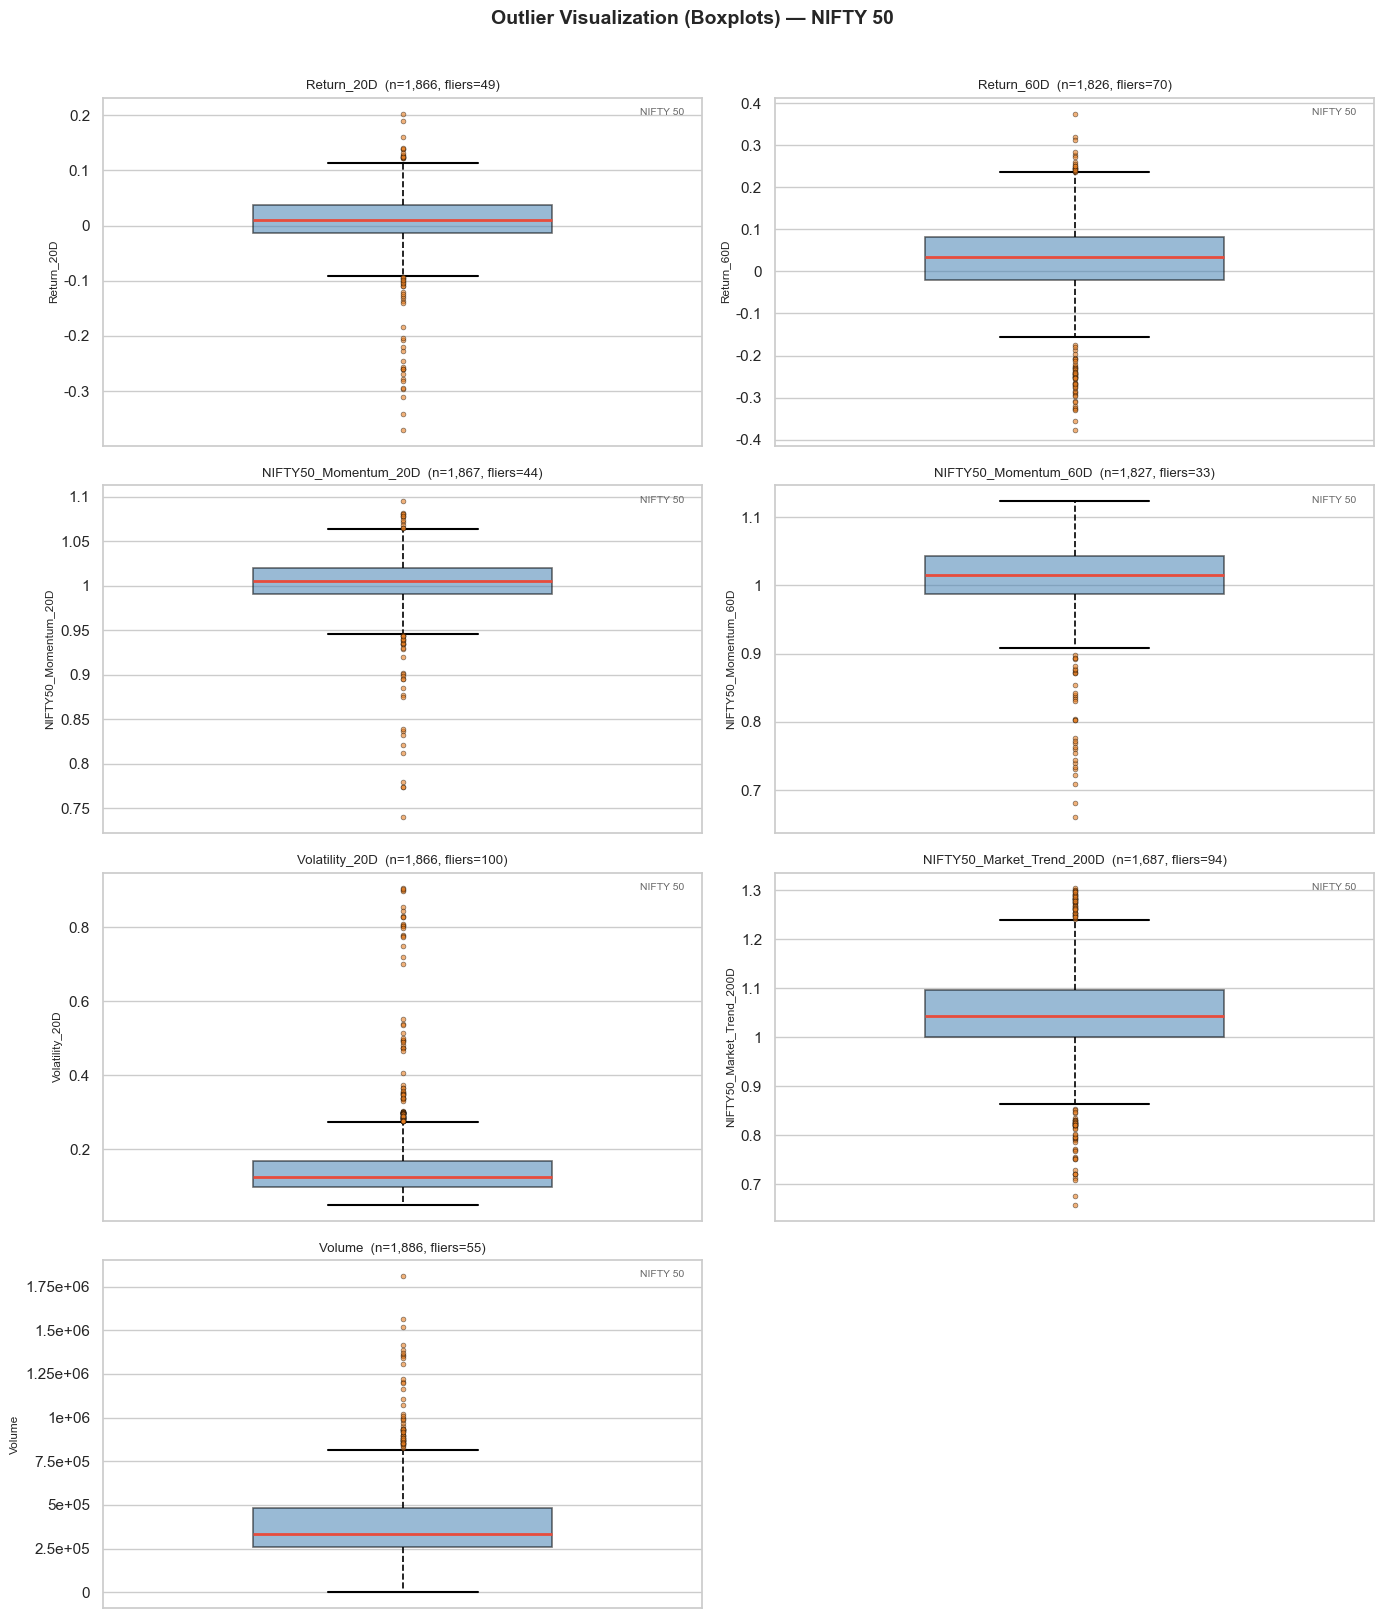

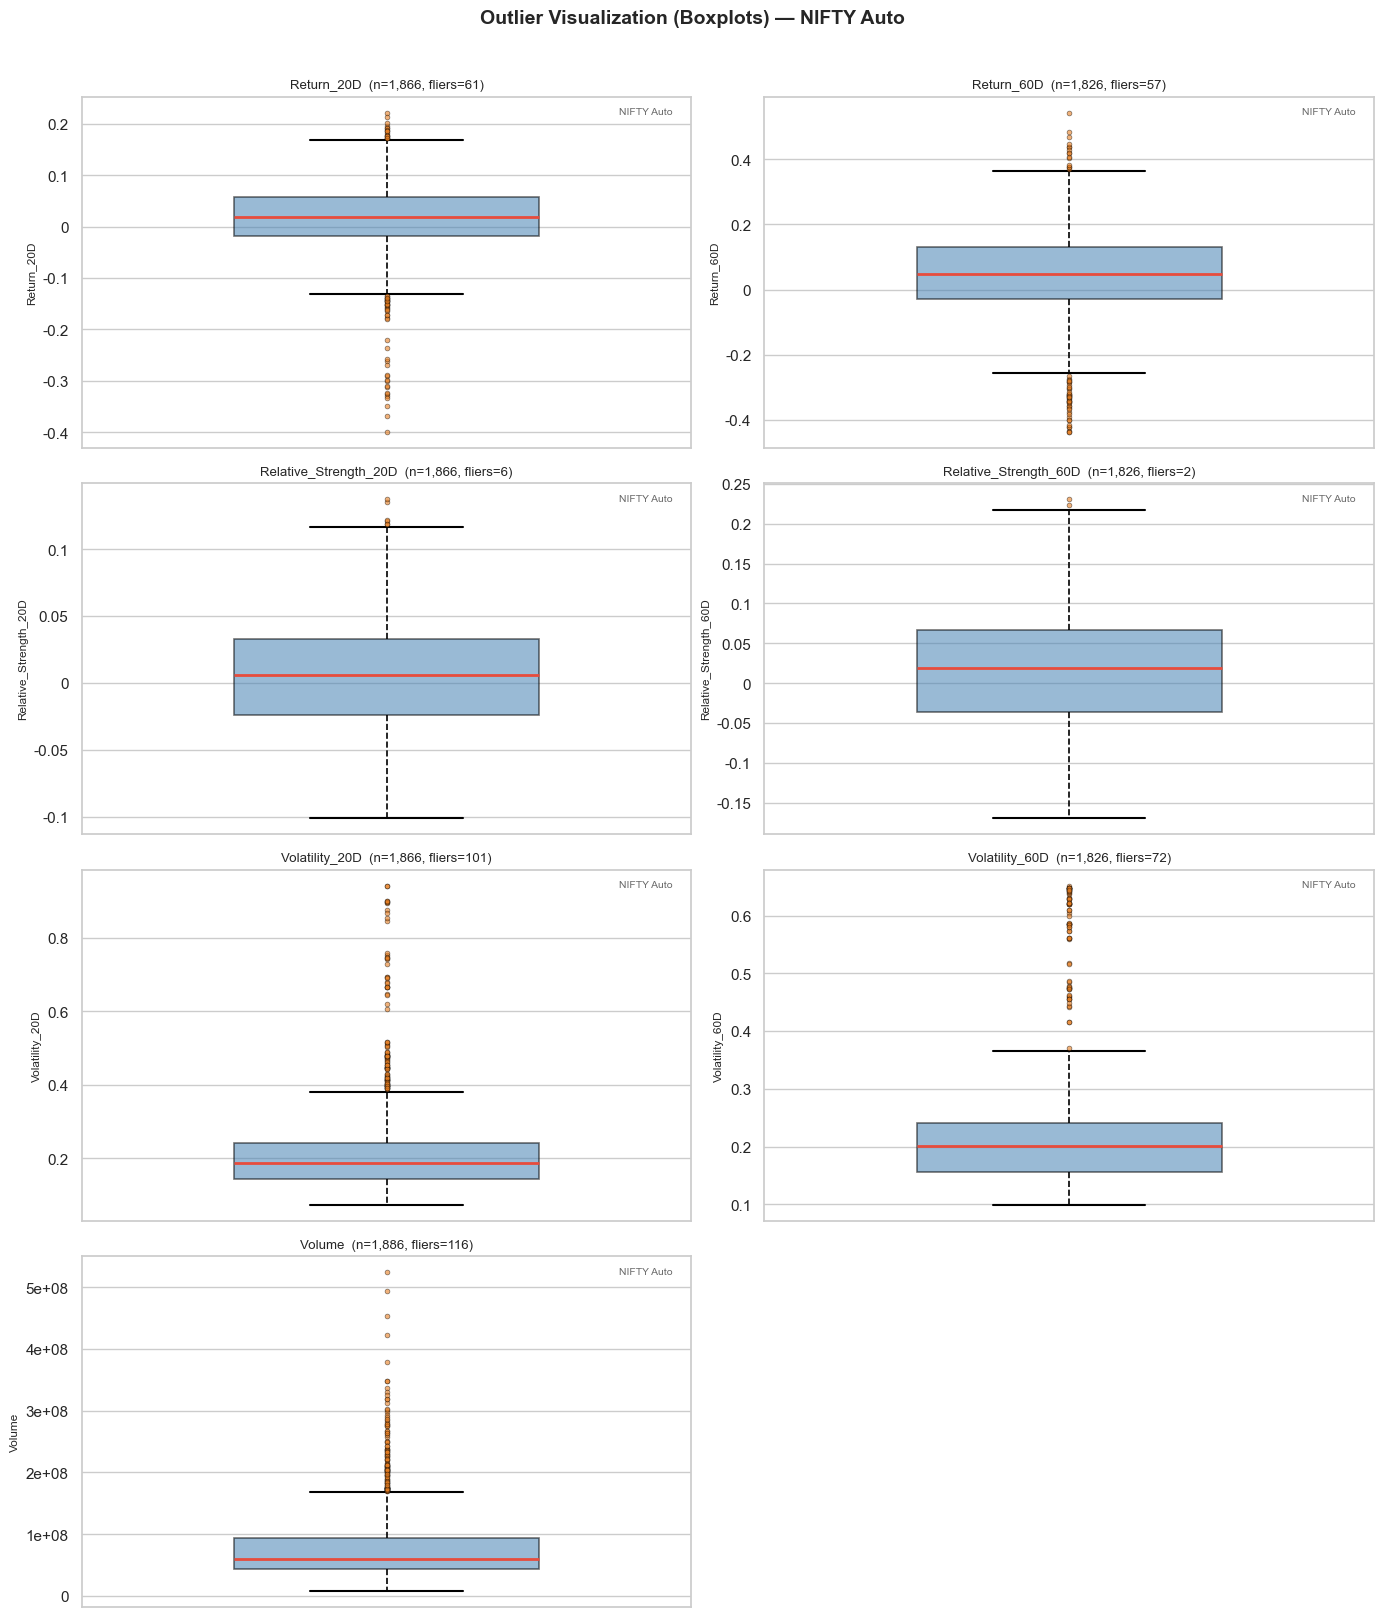

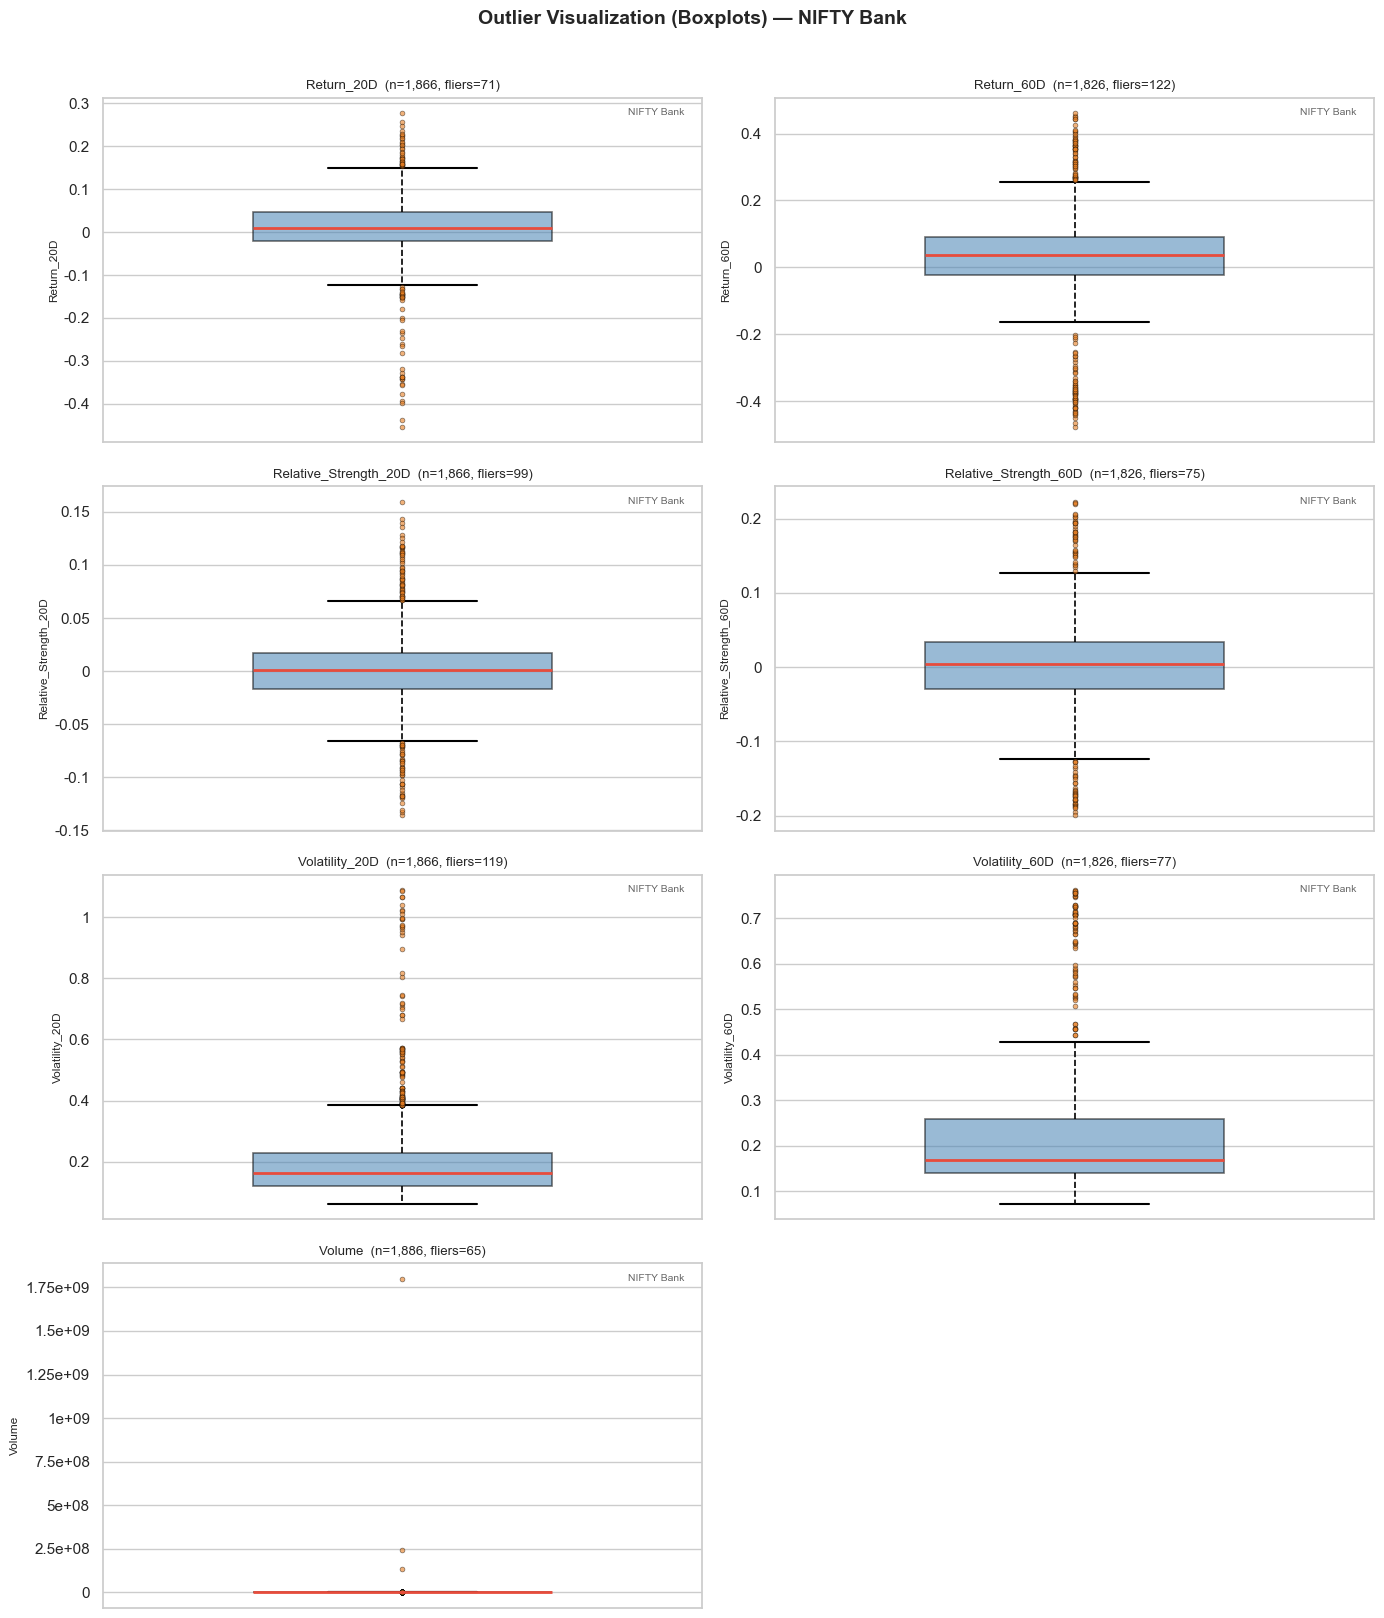

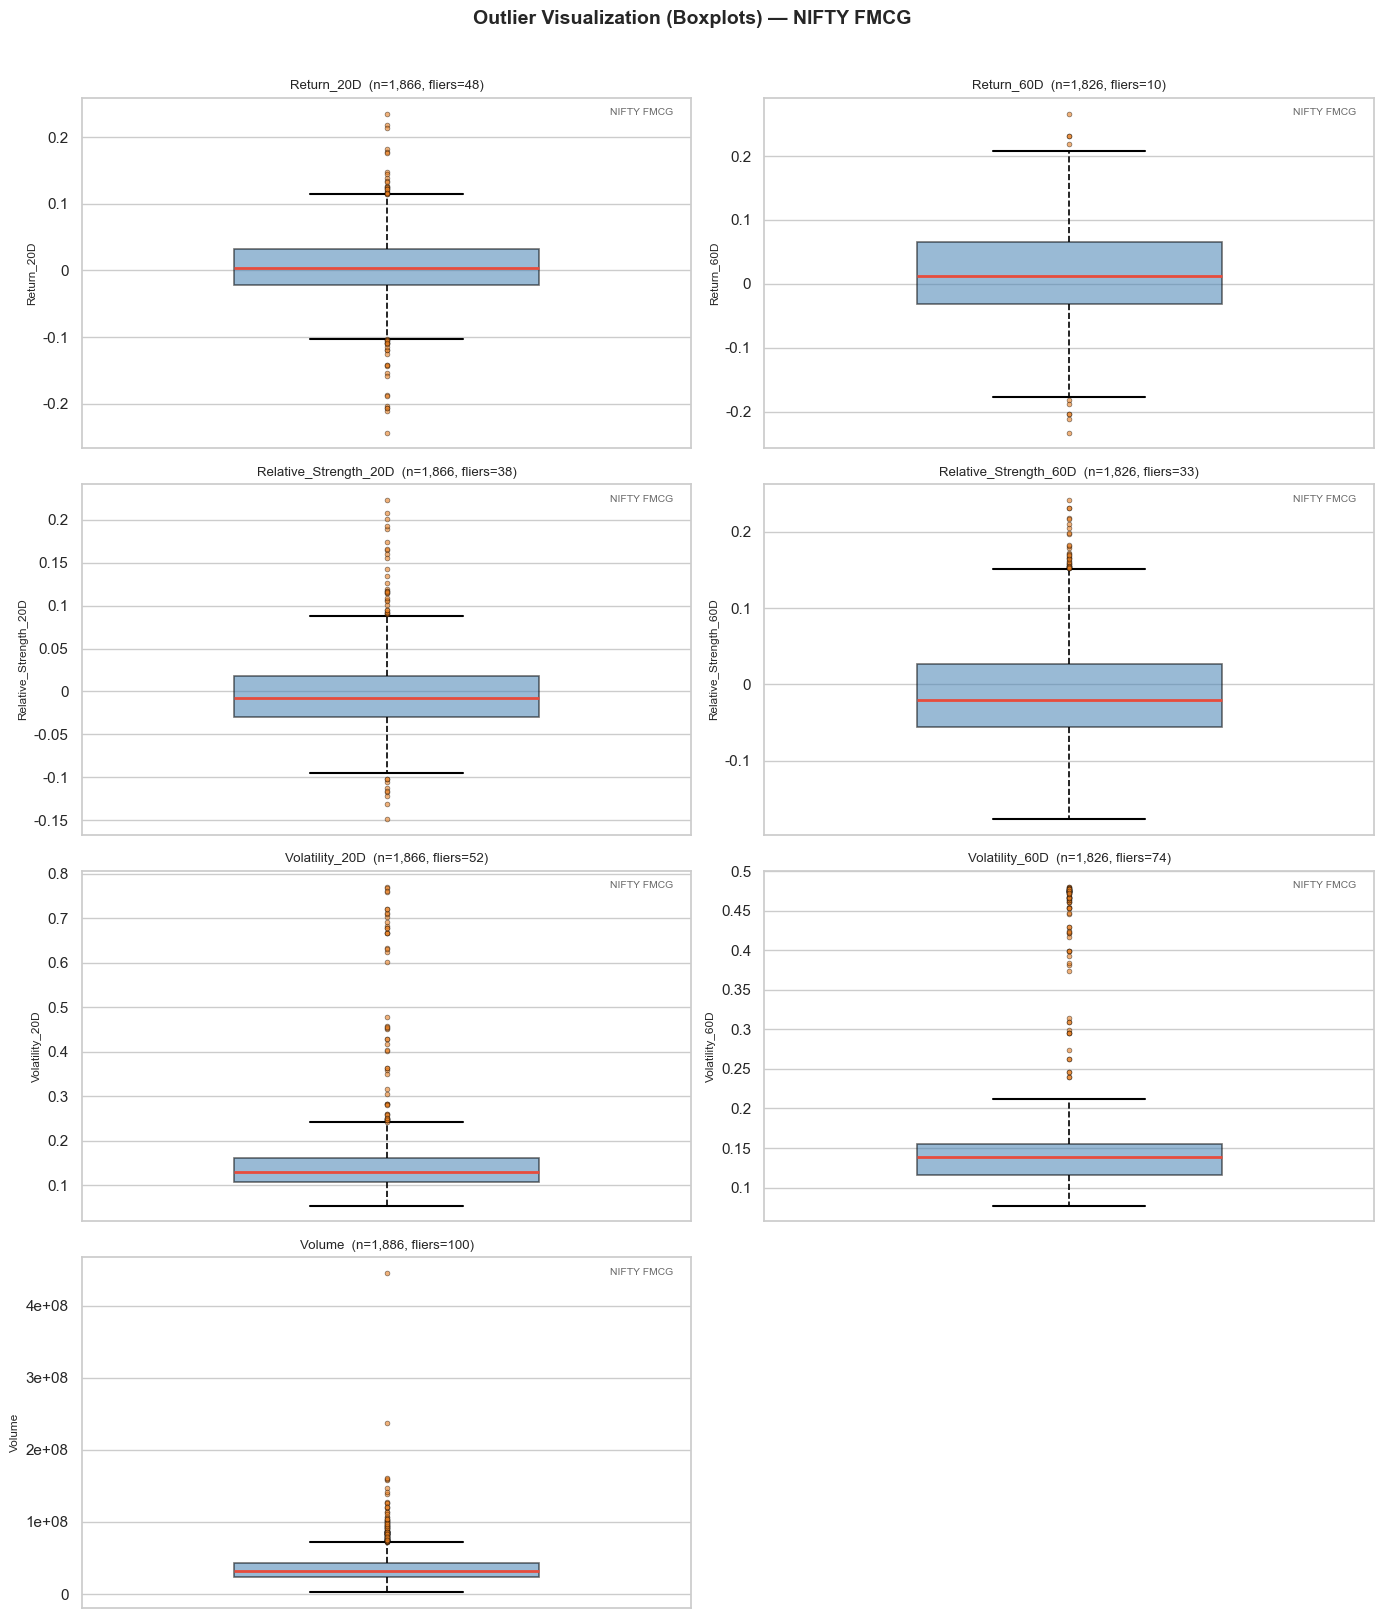

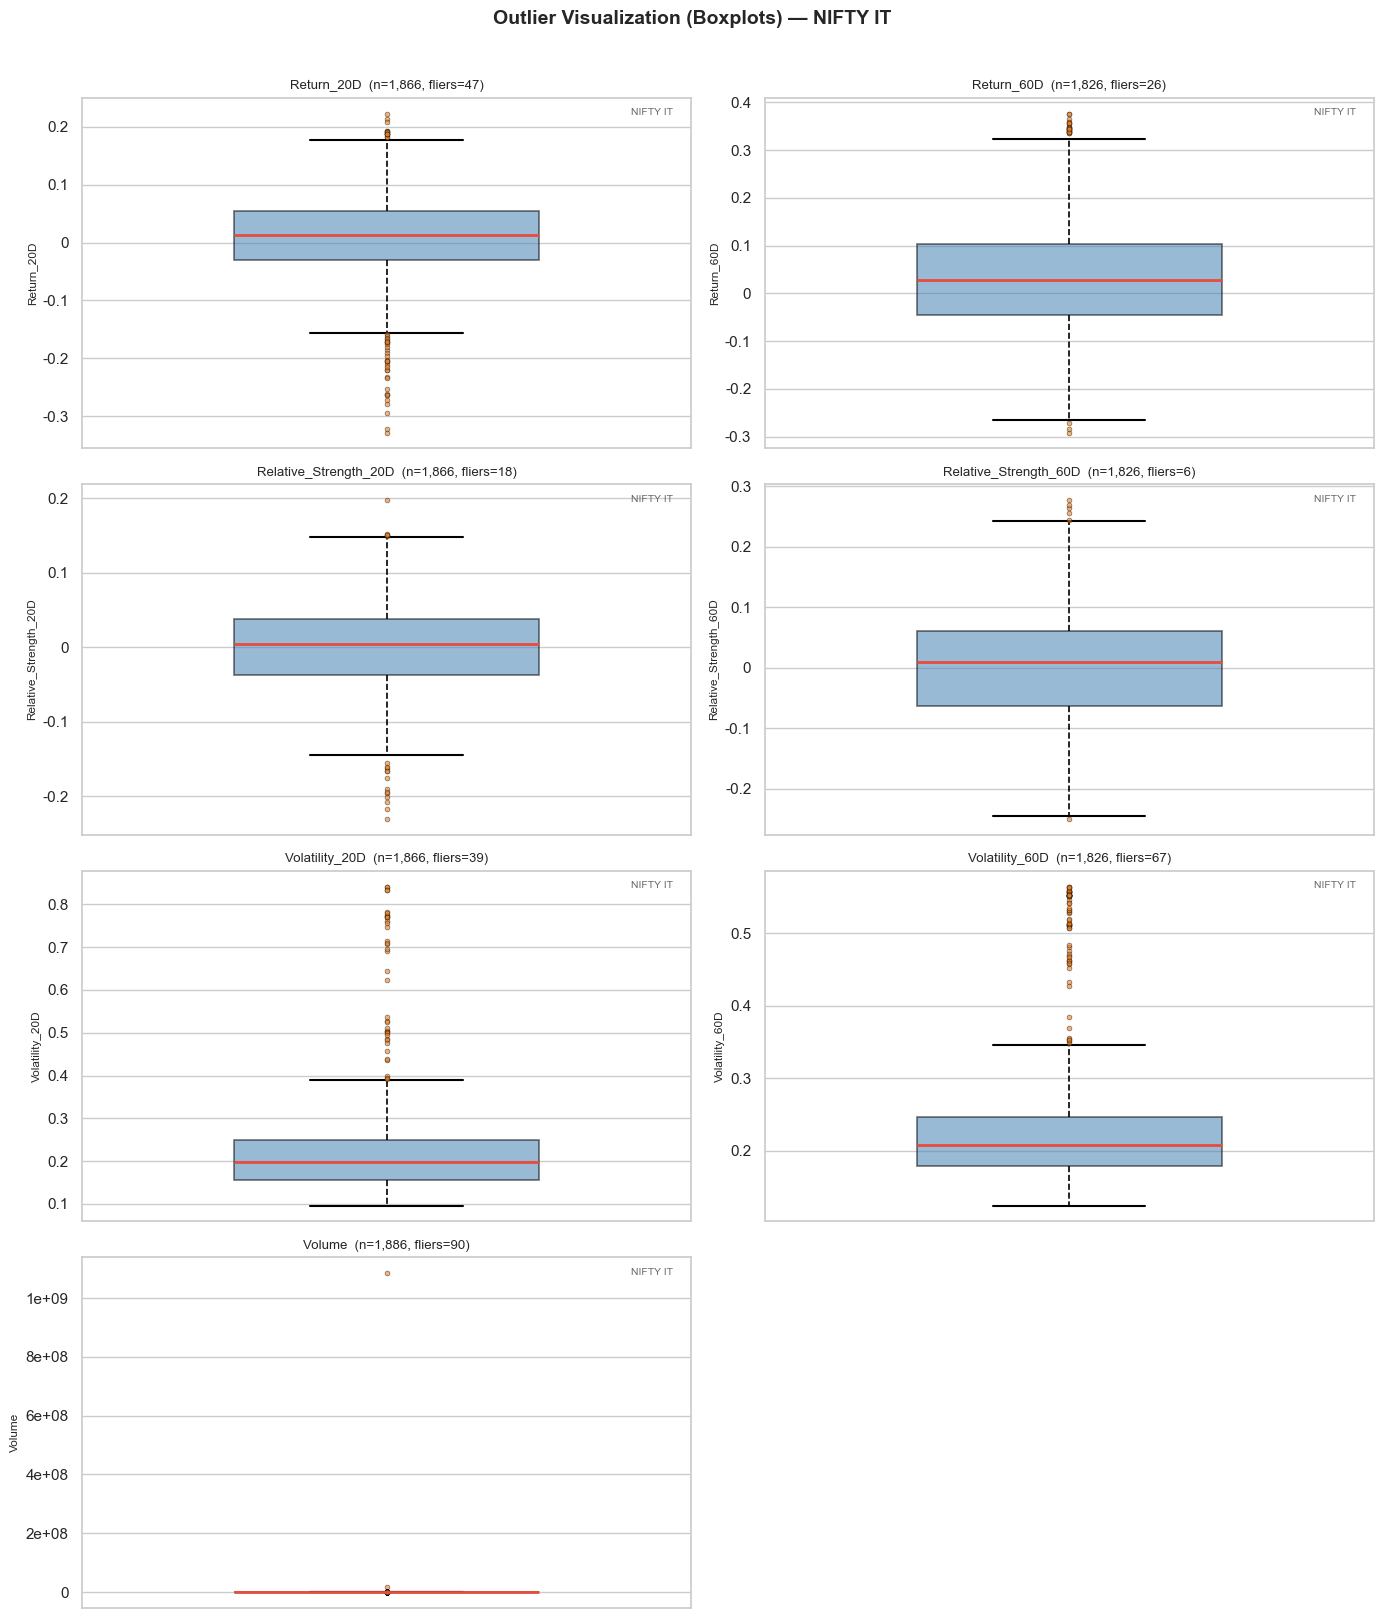

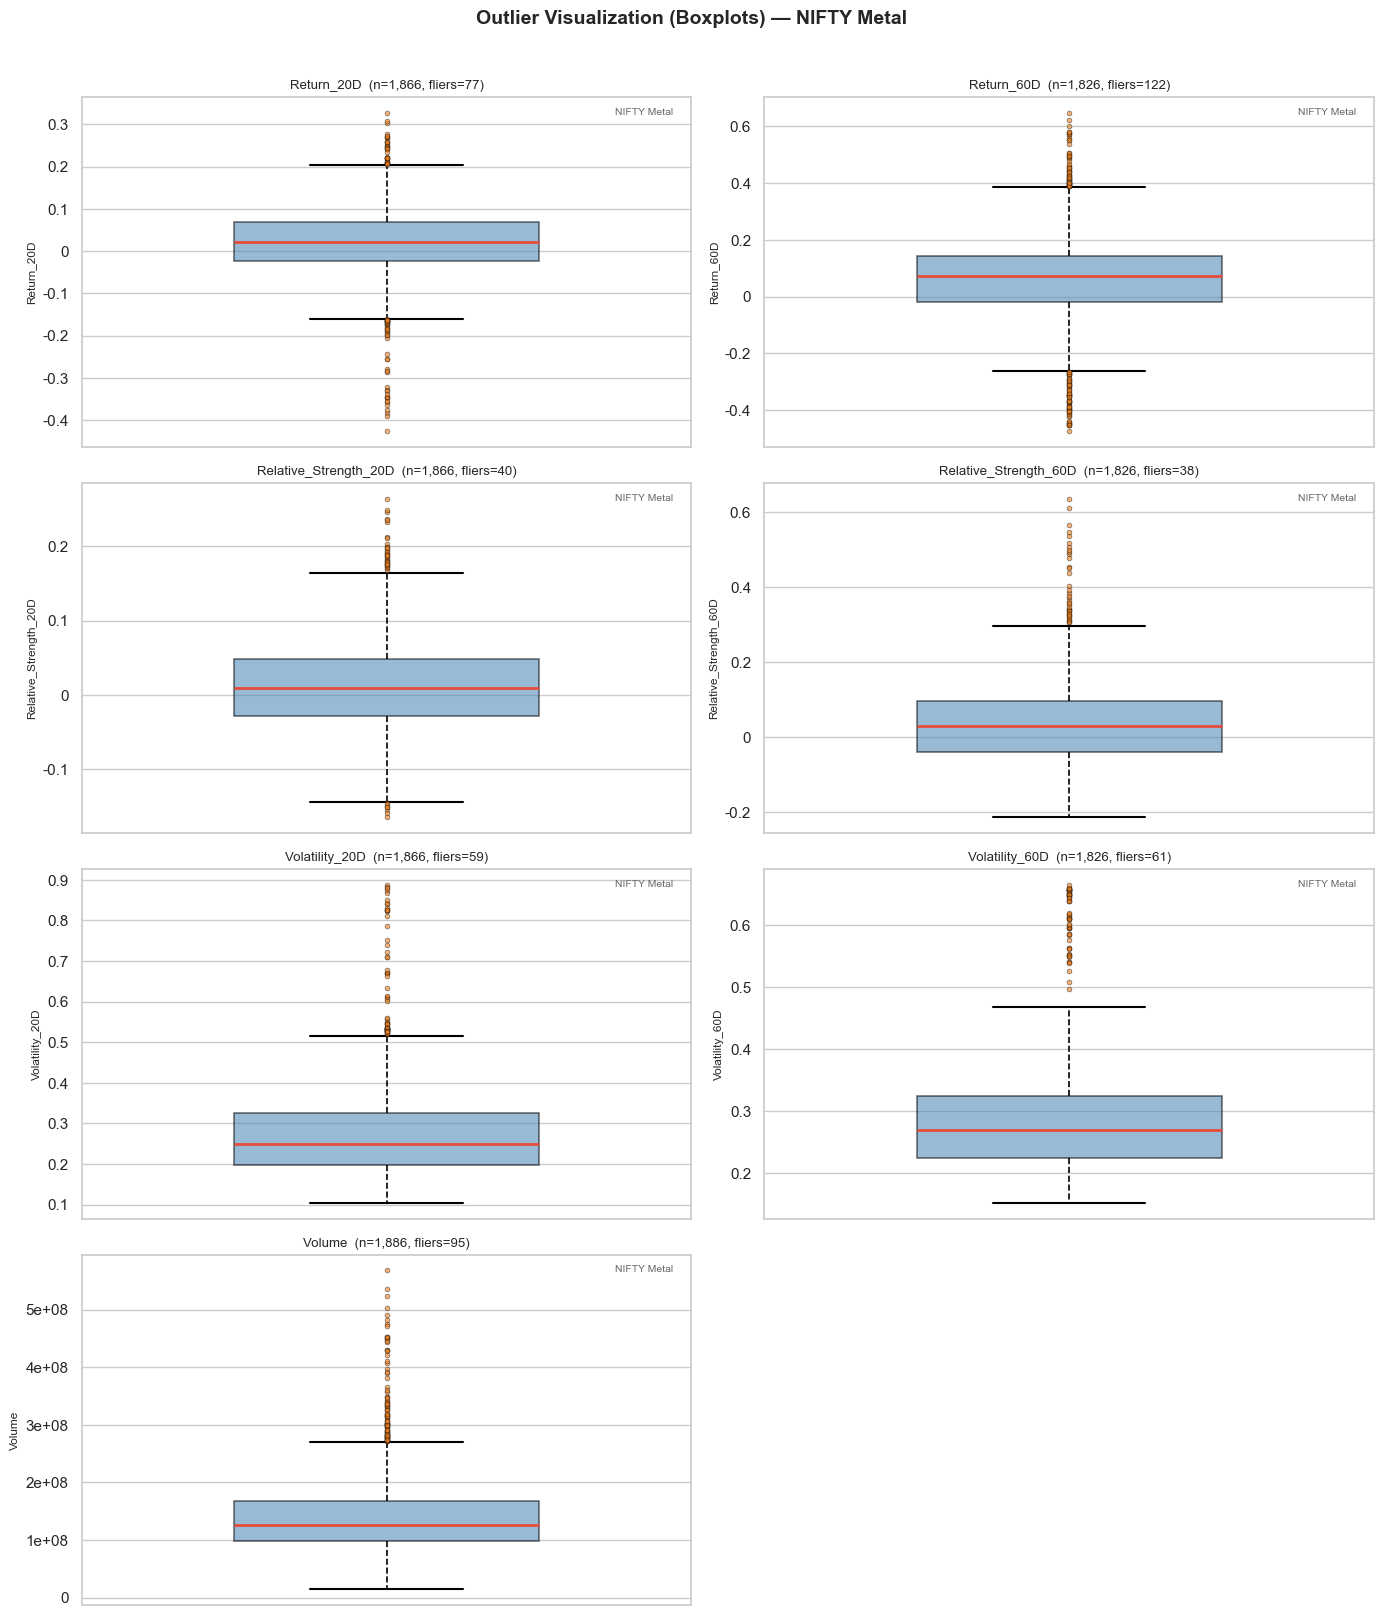

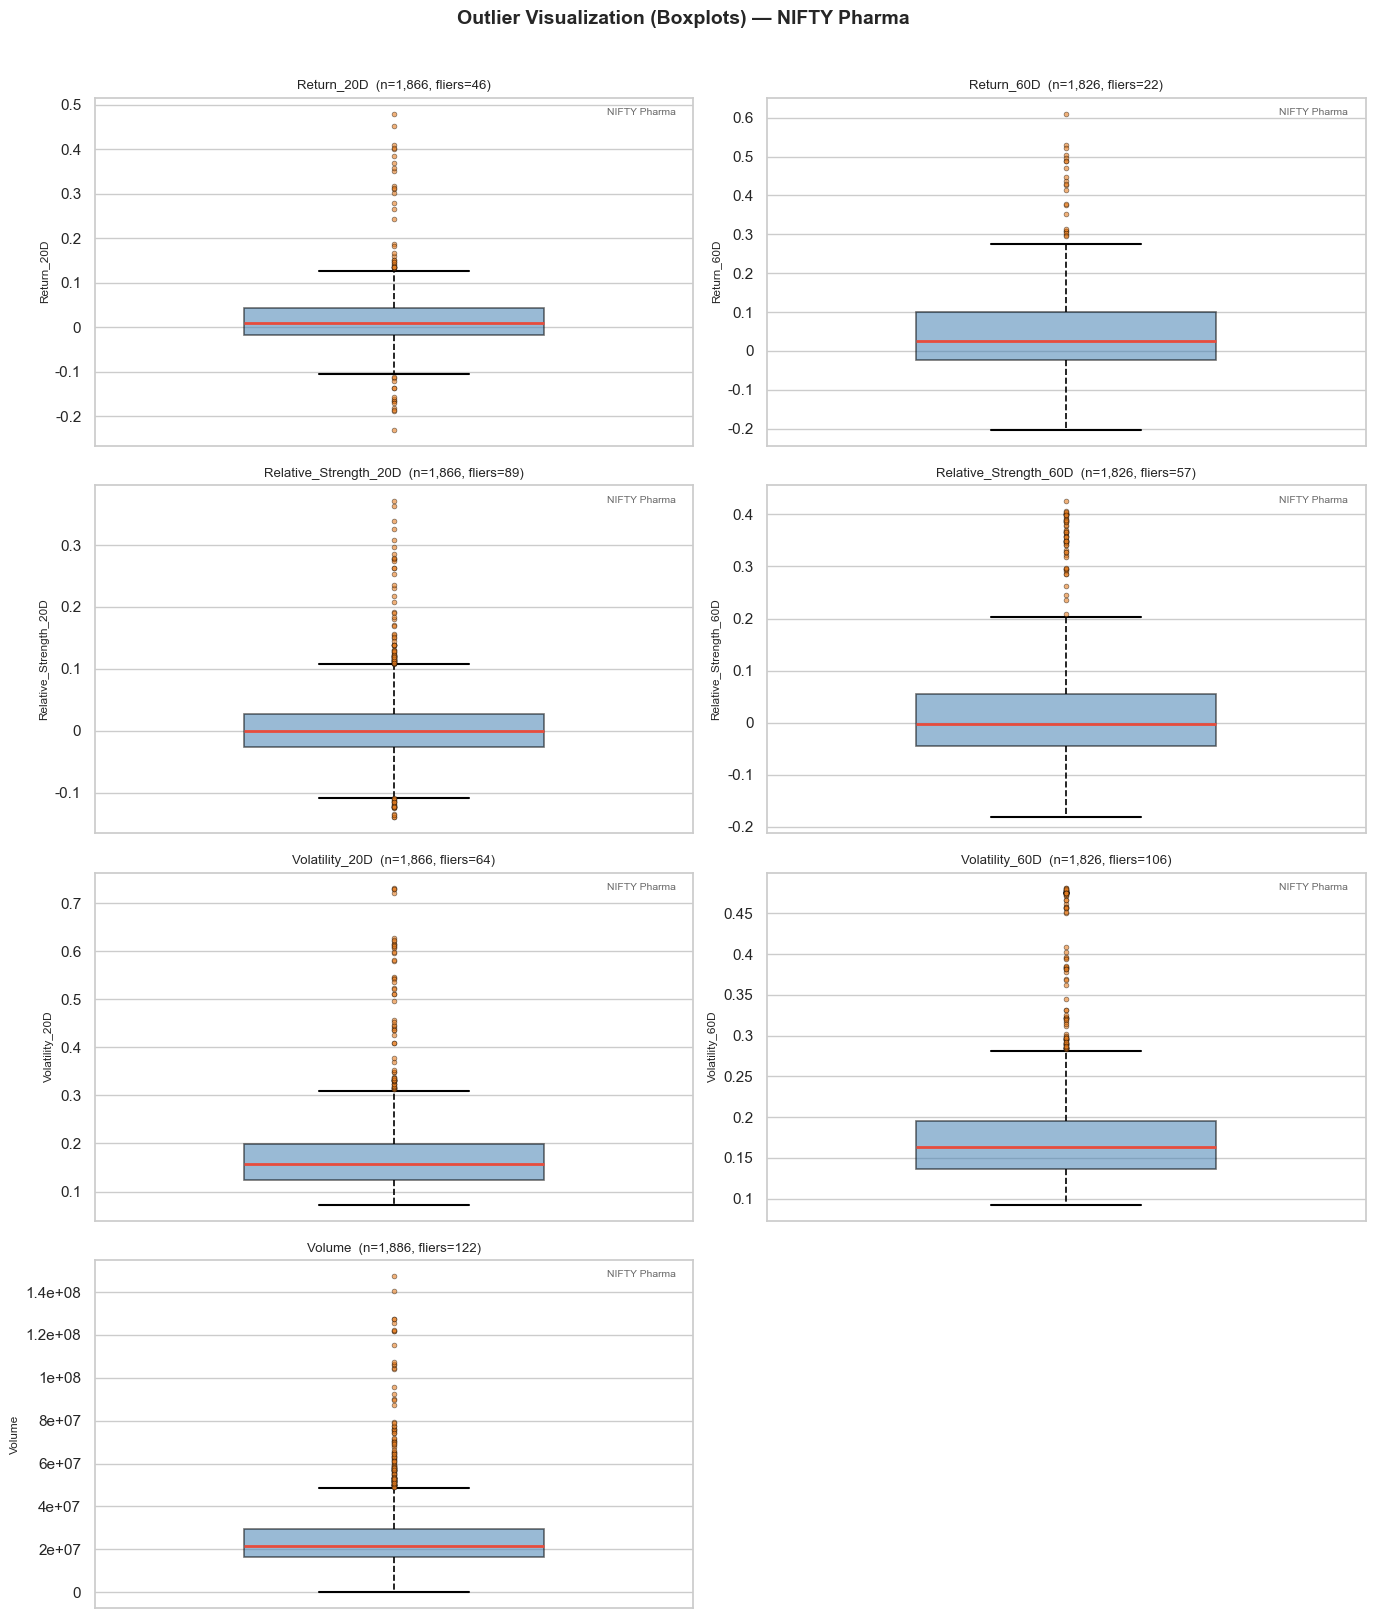

In [11]:
from src.eda import plot_feature_outliers

plot_feature_outliers(
    datasets,
    features_to_plot
)


## infer from 4.2 

1. Extreme observations are common in financial features

They aren't isolated data errors. Returns, volatility, RS and volume all naturally produce observations beyond the IQR boundaries.

2. Volatility and volume have particularly strong upper tails

This confirms what we saw in 4.1.

Their distributions are not just skewed—the boxplots show that extreme high values occur repeatedly.

3. Sector behaviour is different

The number of potential outliers isn't uniform across sectors.

For example:

Bank → many return and RS extremes
Metal → many return extremes
Pharma → many RS and 60D volatility extremes
IT/Auto → comparatively fewer RS extremes

## 4.3 Feature Relationship / Correlation Analysis

Correlation analysis examines pairwise linear relationships between the engineered numerical features within each dataset.

**Purpose:** To identify potentially redundant feature pairs — pairs that carry heavily overlapping information — which may be relevant when selecting features for the ML model.

**Method:** Pearson correlation coefficient (*r*), computed pairwise over non-NaN observations. Each heatmap displays the full correlation matrix for one dataset.

**How to read the results:**
- *r* close to **+1.0** → strong positive relationship (features tend to move together)
- *r* close to **−1.0** → strong negative relationship (features tend to move in opposite directions)
- *r* close to **0** → weak or no linear relationship

**Important:** A strong correlation does not by itself justify removing a feature. Redundancy is one piece of evidence, but it must be considered alongside distribution shape, outlier behaviour, sector comparisons, and time-series behaviour. Final feature selection will be performed only after the complete EDA in Step 4.7.


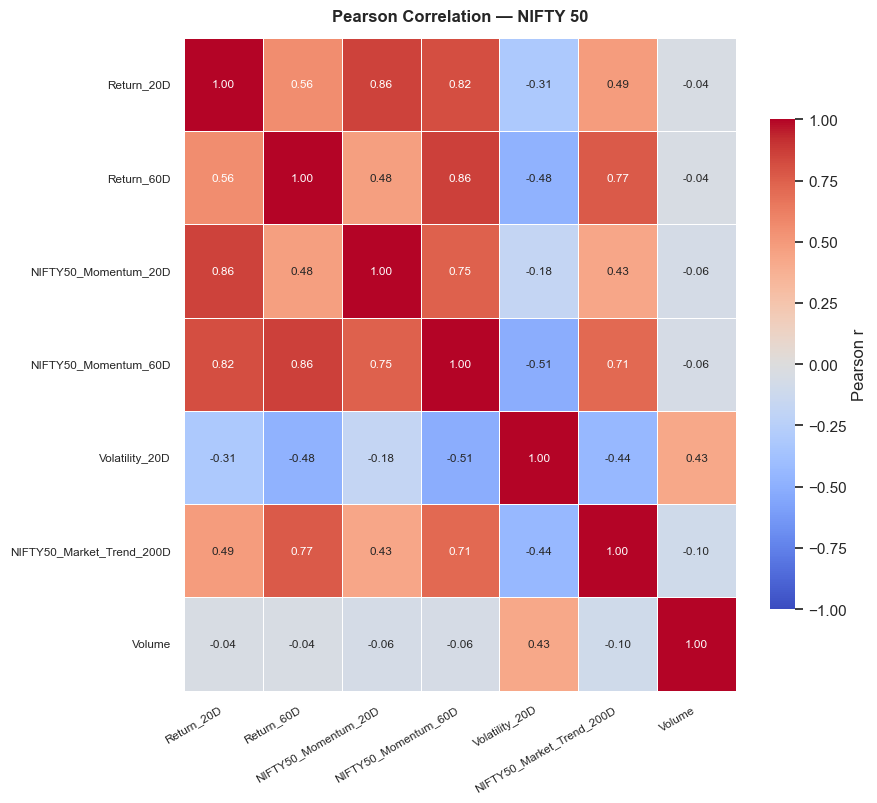

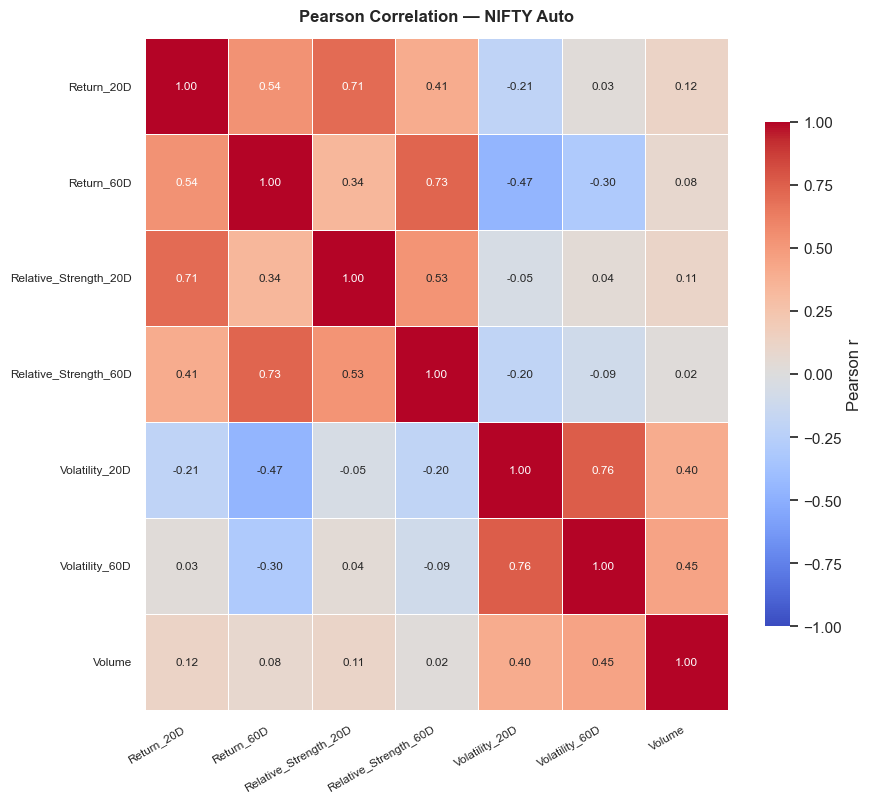

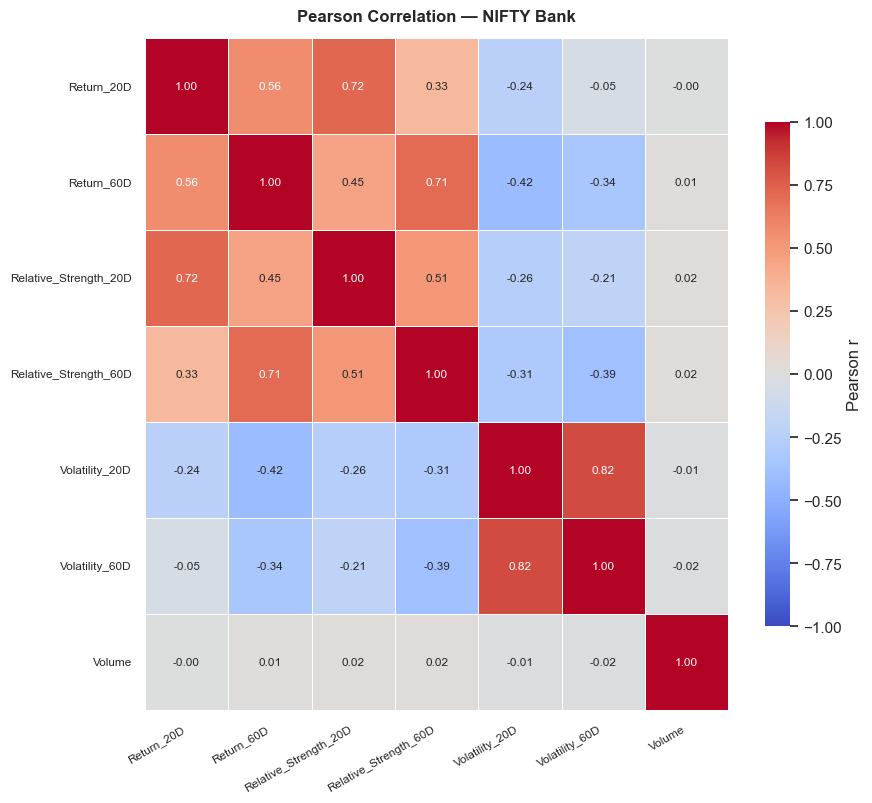

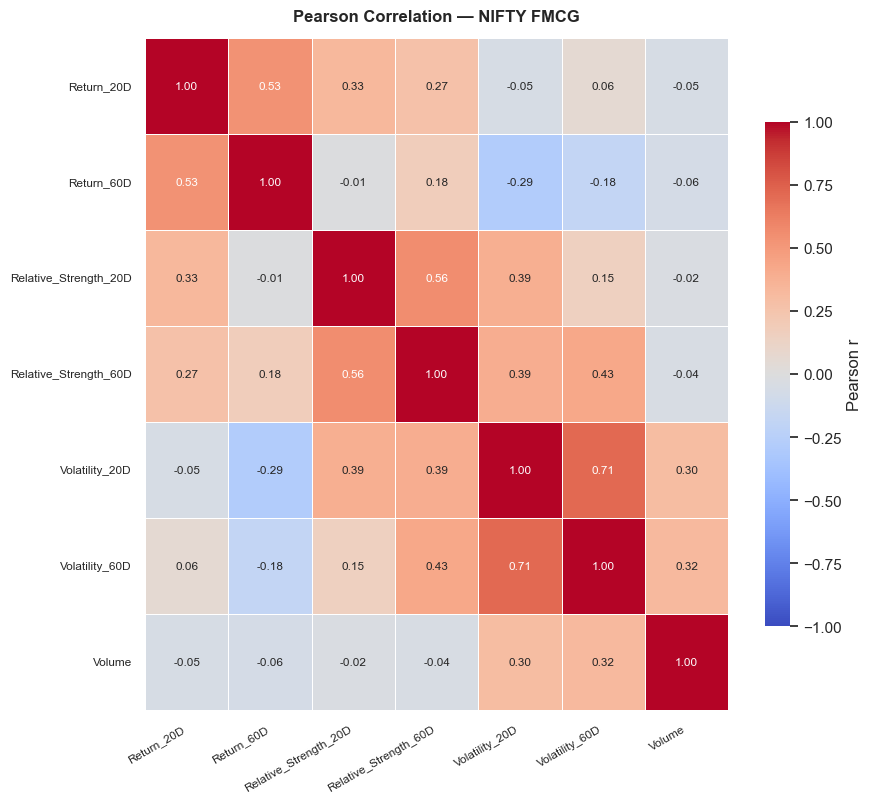

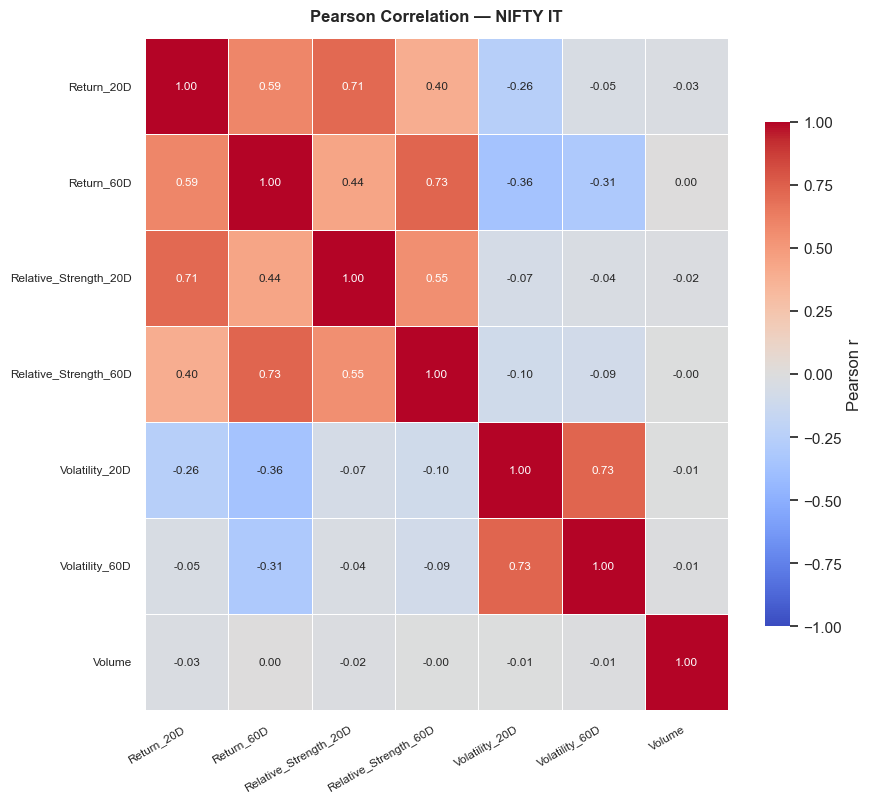

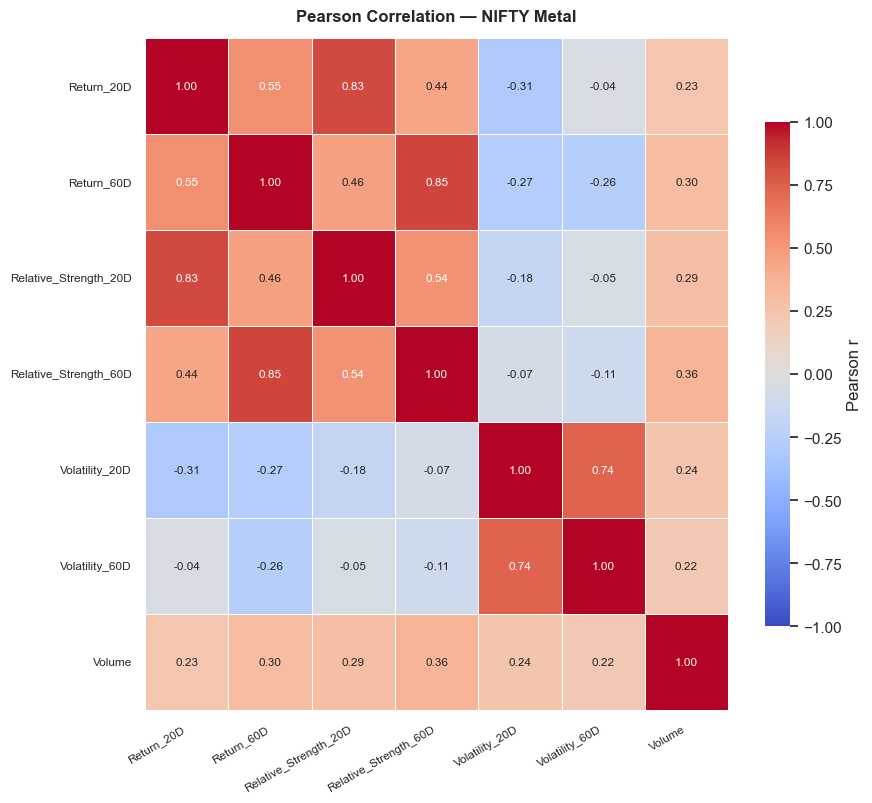

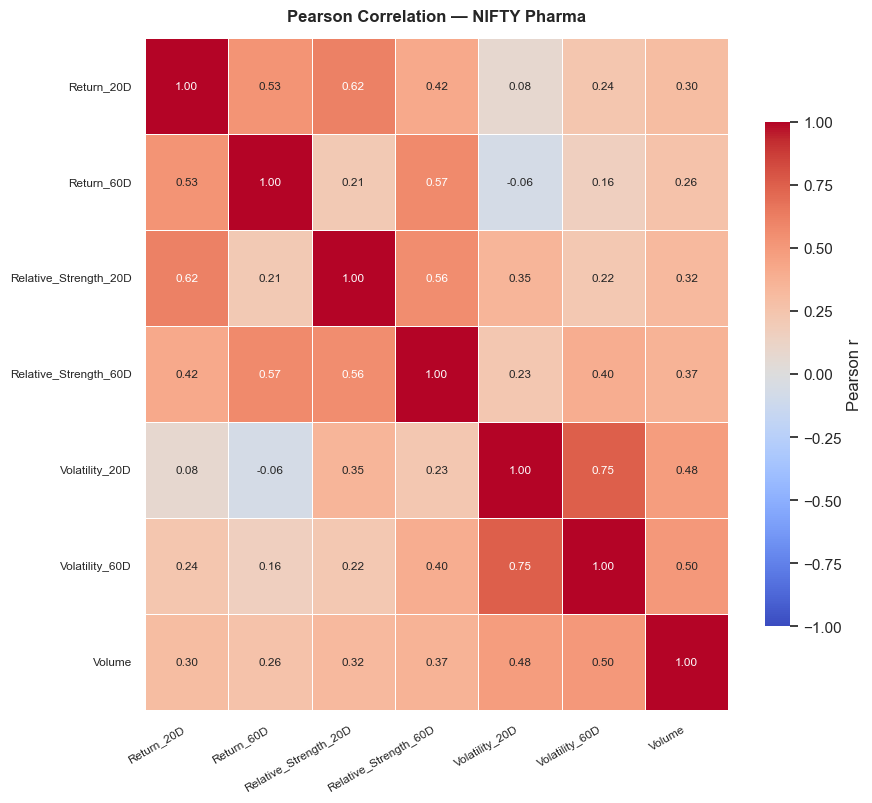

In [12]:

from src.eda import plot_feature_correlations

plot_feature_correlations(datasets, features_to_plot)


## inference from 4.3

The correlation analysis shows that several features are related, particularly features calculated over different time horizons. Volatility 20D and 60D show consistently strong correlations across sectors, indicating substantial overlap. Returns and relative strength are also often strongly related, but relative strength provides additional information about sector performance relative to NIFTY 50. NIFTY 50 momentum and market-trend features are also strongly related to returns. Volume generally has weaker relationships with the other features, suggesting potentially distinct information, although its reliability remains a concern because of the zero-volume observations. Therefore, correlation analysis identifies potential redundancy but does not by itself determine which features should be removed.

## 4.4 Sector Comparison

This section compares the six sector indices — NIFTY Auto, NIFTY Bank, NIFTY FMCG, NIFTY IT, NIFTY Metal, and NIFTY Pharma — across the primary engineered features to examine whether their statistical behaviour differs meaningfully.

The purpose is to understand:
- whether sectors differ in typical return behaviour (Return_20D, Return_60D);
- whether sectors differ in their strength relative to the benchmark (Relative_Strength_20D, Relative_Strength_60D);
- whether sectors operate at different volatility levels (Volatility_20D, Volatility_60D).

Grouped boxplots are used to compare the distribution of each feature across all six sectors simultaneously. Each plot shows one feature; the six sector boxes are placed side-by-side for direct comparison. Whiskers follow the standard Tukey 1.5 × IQR rule.

**Volume is excluded** from this primary comparison because of the previously identified data-quality and reliability issues (zero-volume observations in NIFTY Bank, NIFTY IT, and to a lesser extent NIFTY 50 and NIFTY Pharma). Volume will be addressed separately.

**NIFTY 50 is excluded** from the sector comparison because it serves as the benchmark/reference index rather than one of the six sector indices.

This analysis is purely descriptive. No sectors are ranked, no investment recommendations are made, and no feature-selection decisions are taken here. Final feature selection is deferred to Section 4.7.


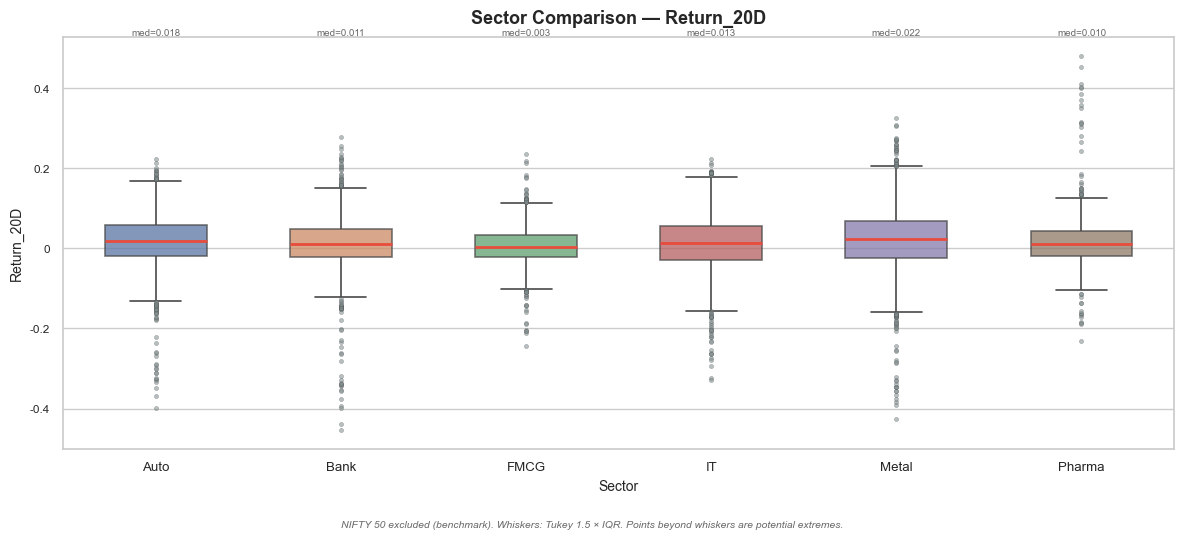

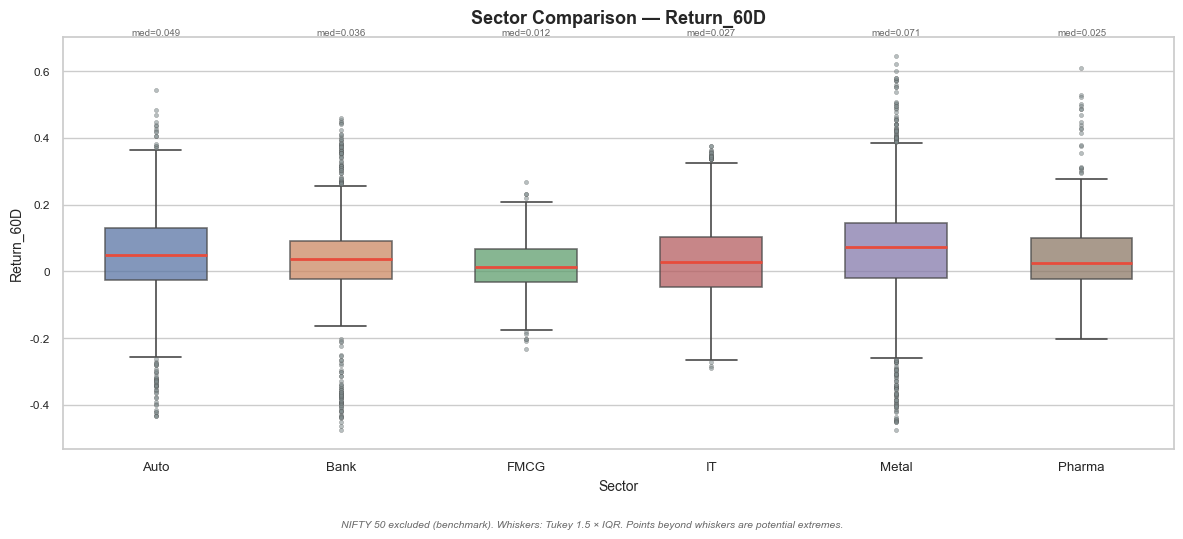

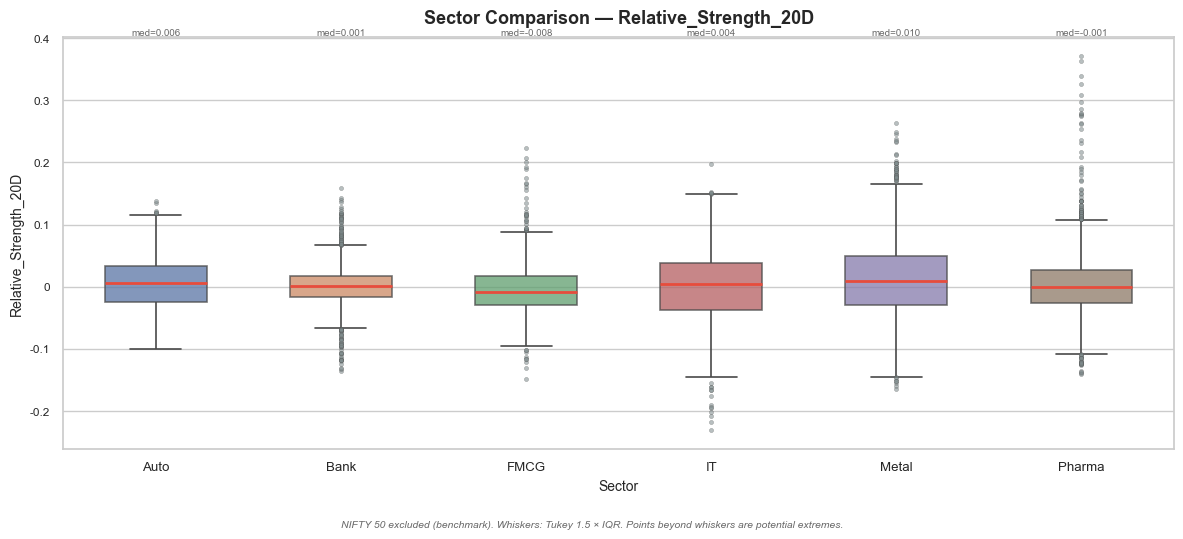

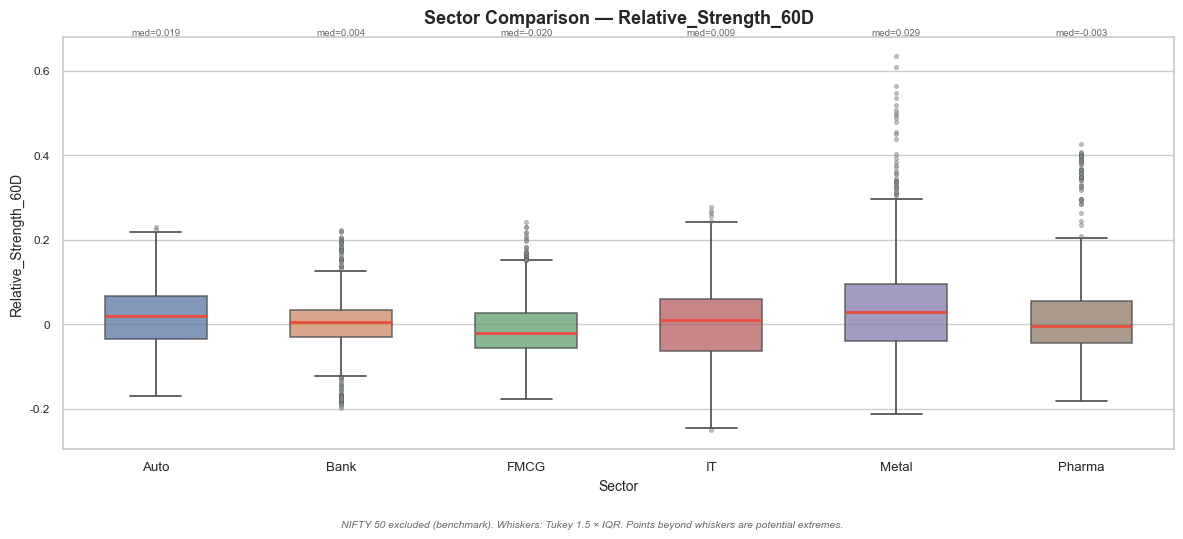

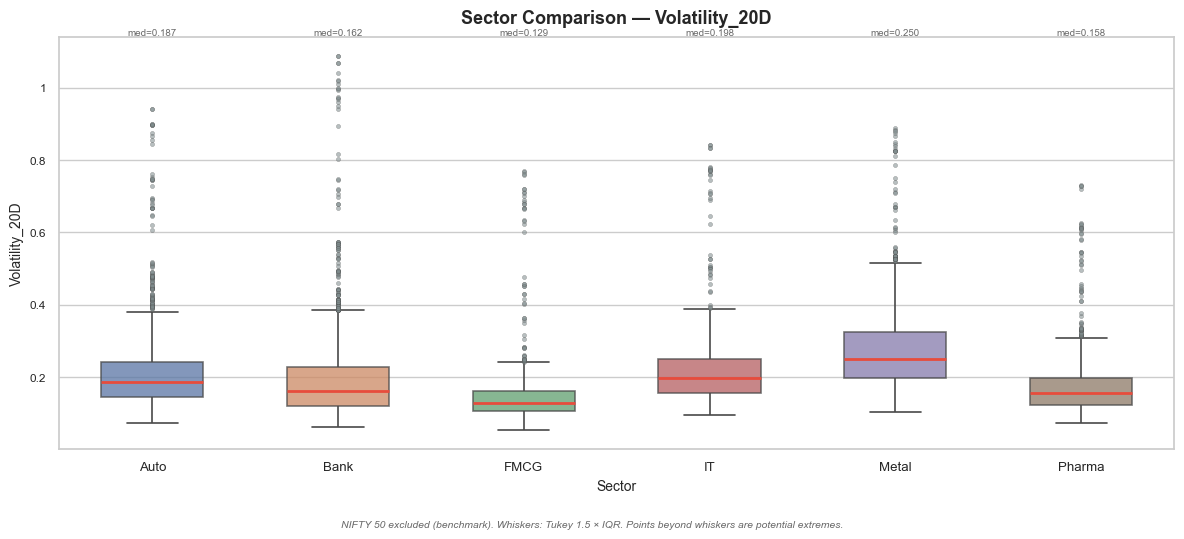

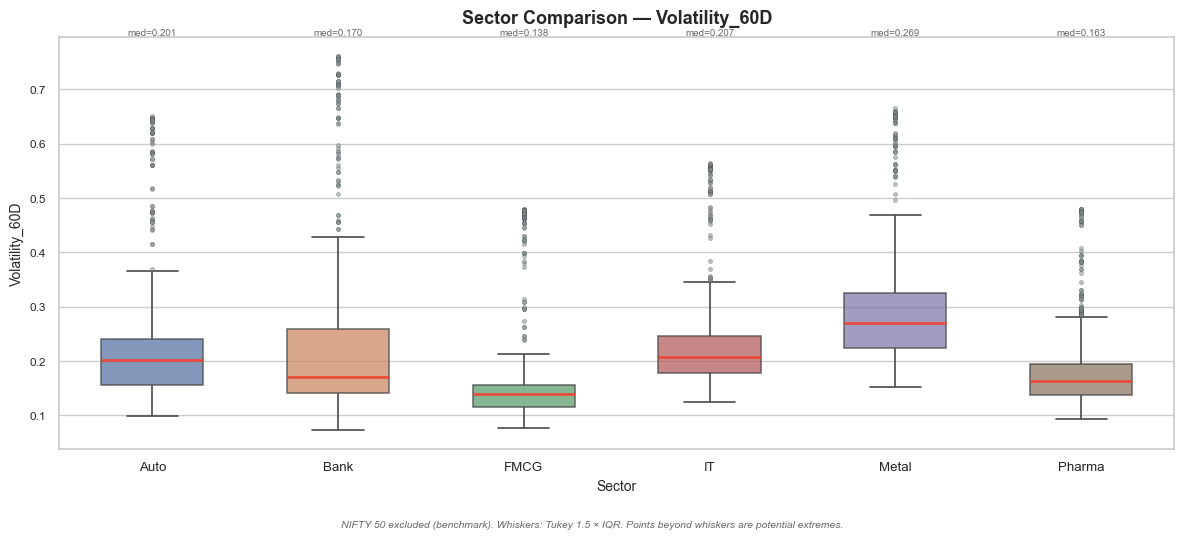

In [13]:
from src.eda import plot_sector_comparison

sector_comparison_features = [
    "Return_20D",
    "Return_60D",
    "Relative_Strength_20D",
    "Relative_Strength_60D",
    "Volatility_20D",
    "Volatility_60D",
]

plot_sector_comparison(datasets, sector_comparison_features)


## infer from 4.4 

The six sectors do not have identical statistical behaviour. Their return, relative-strength, and volatility distributions differ in terms of central tendency, spread, and extreme observations. In particular, volatility shows clear differences in typical levels across sectors, while relative strength demonstrates differences in sector performance relative to NIFTY 50. These differences indicate that the engineered features capture sector-specific characteristics that may be useful for identifying different market and sector regimes.

## 4.5 Time-Series / Sector Behaviour

This section examines how the engineered features evolve through time across the date range 2019-01-02 to 2026-09-18.

Line plots are used to observe temporal behaviour with Date on the x-axis. The focus is on three primary features:

- **Return_20D** — how sector return momentum changes across market periods
- **Relative_Strength_20D** — how sector performance relative to NIFTY 50 shifts over time
- **Volatility_20D** — how volatility rises and falls, including periods of elevated market stress

The six sector indices are overlaid on a shared y-scale per feature so that sector similarities and divergences are directly visible. A separate stacked plot shows NIFTY 50 market-level features (Return_20D, Volatility_20D, and Market_Trend_200D) on aligned time axes.

The objective is to understand whether sectors behave differently across different market periods and whether the features show temporal patterns that could support later regime discovery.

No regimes are manually defined at this stage. Event-based interpretation is deferred to Section 4.6. Volume is excluded from the primary time-series comparison because of the previously identified data-quality issue. Final feature-selection decisions are deferred to Section 4.7.


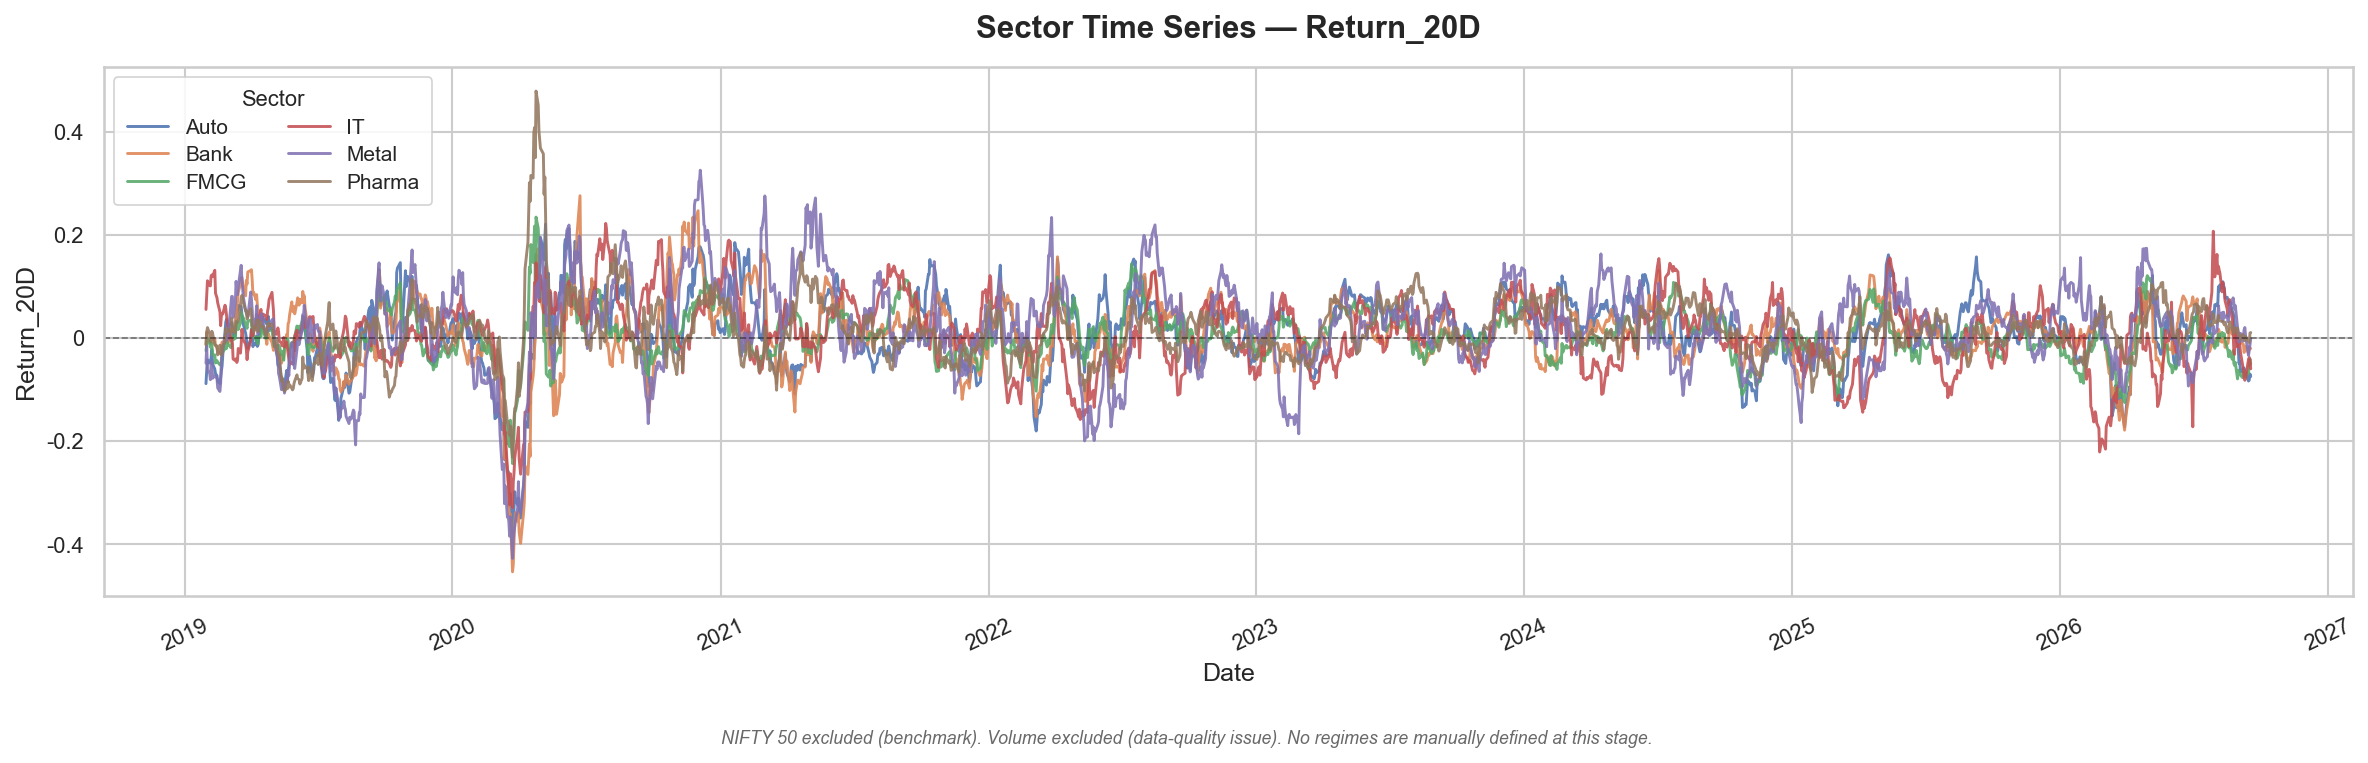

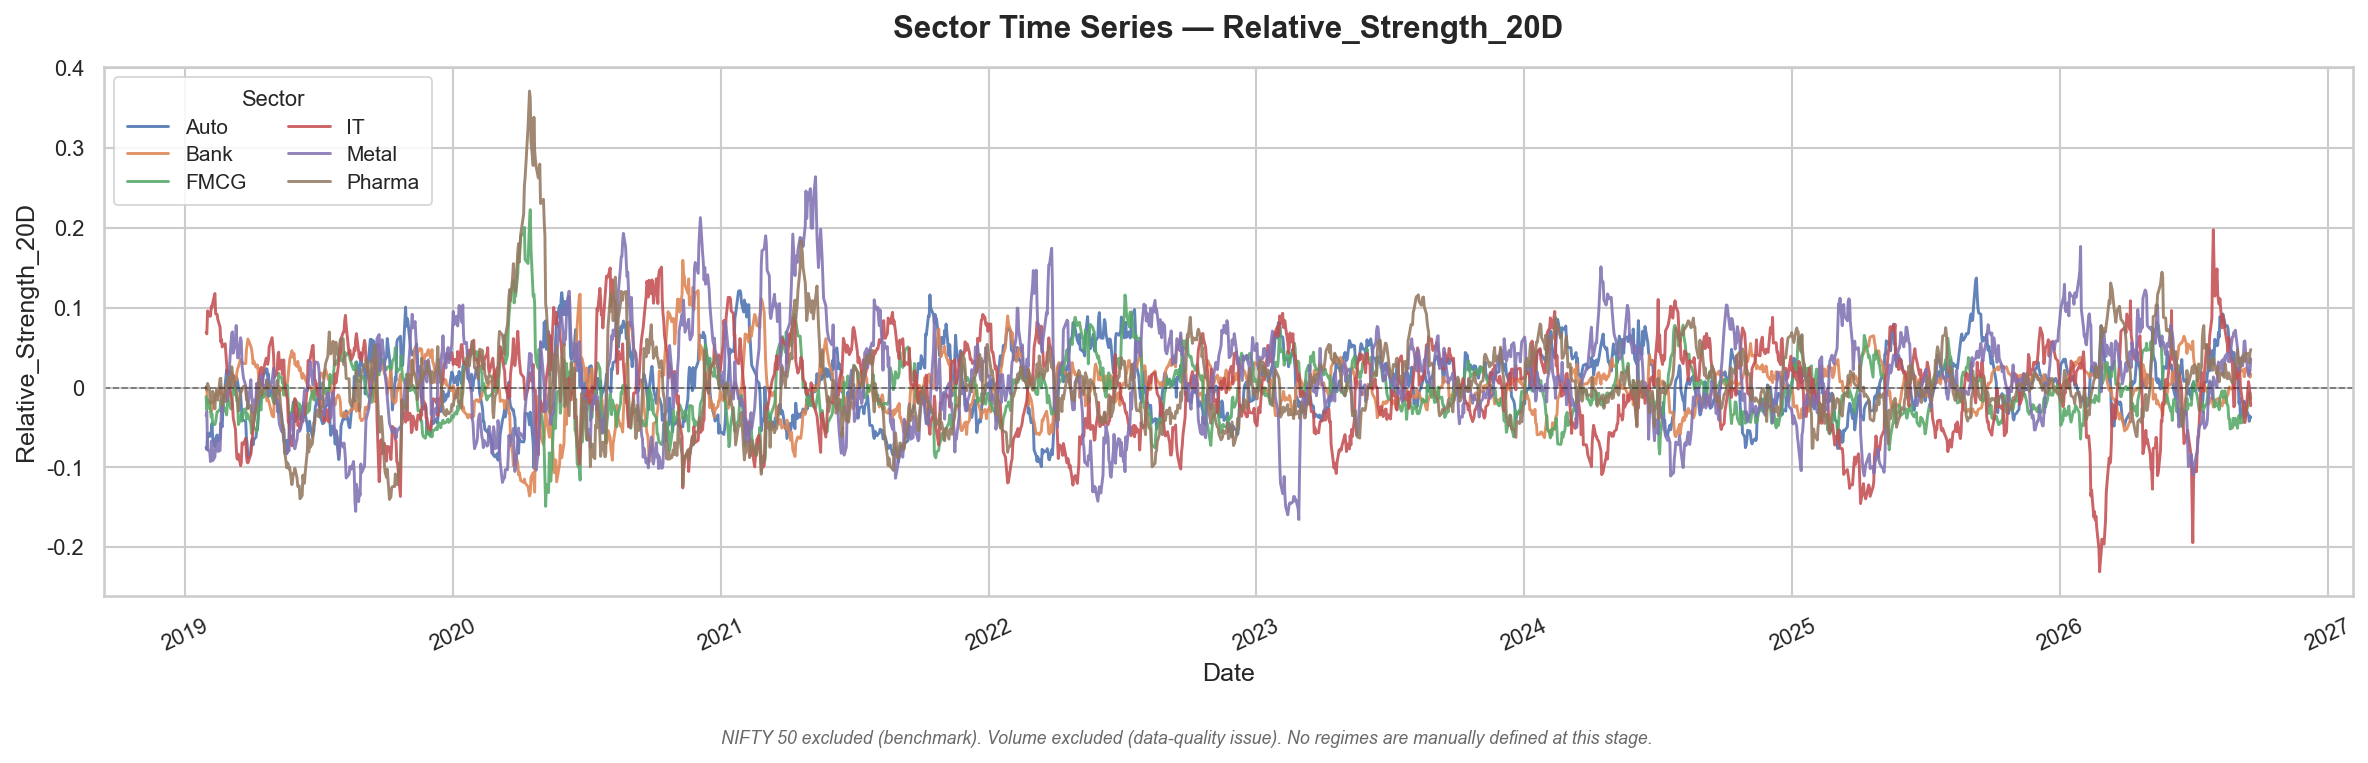

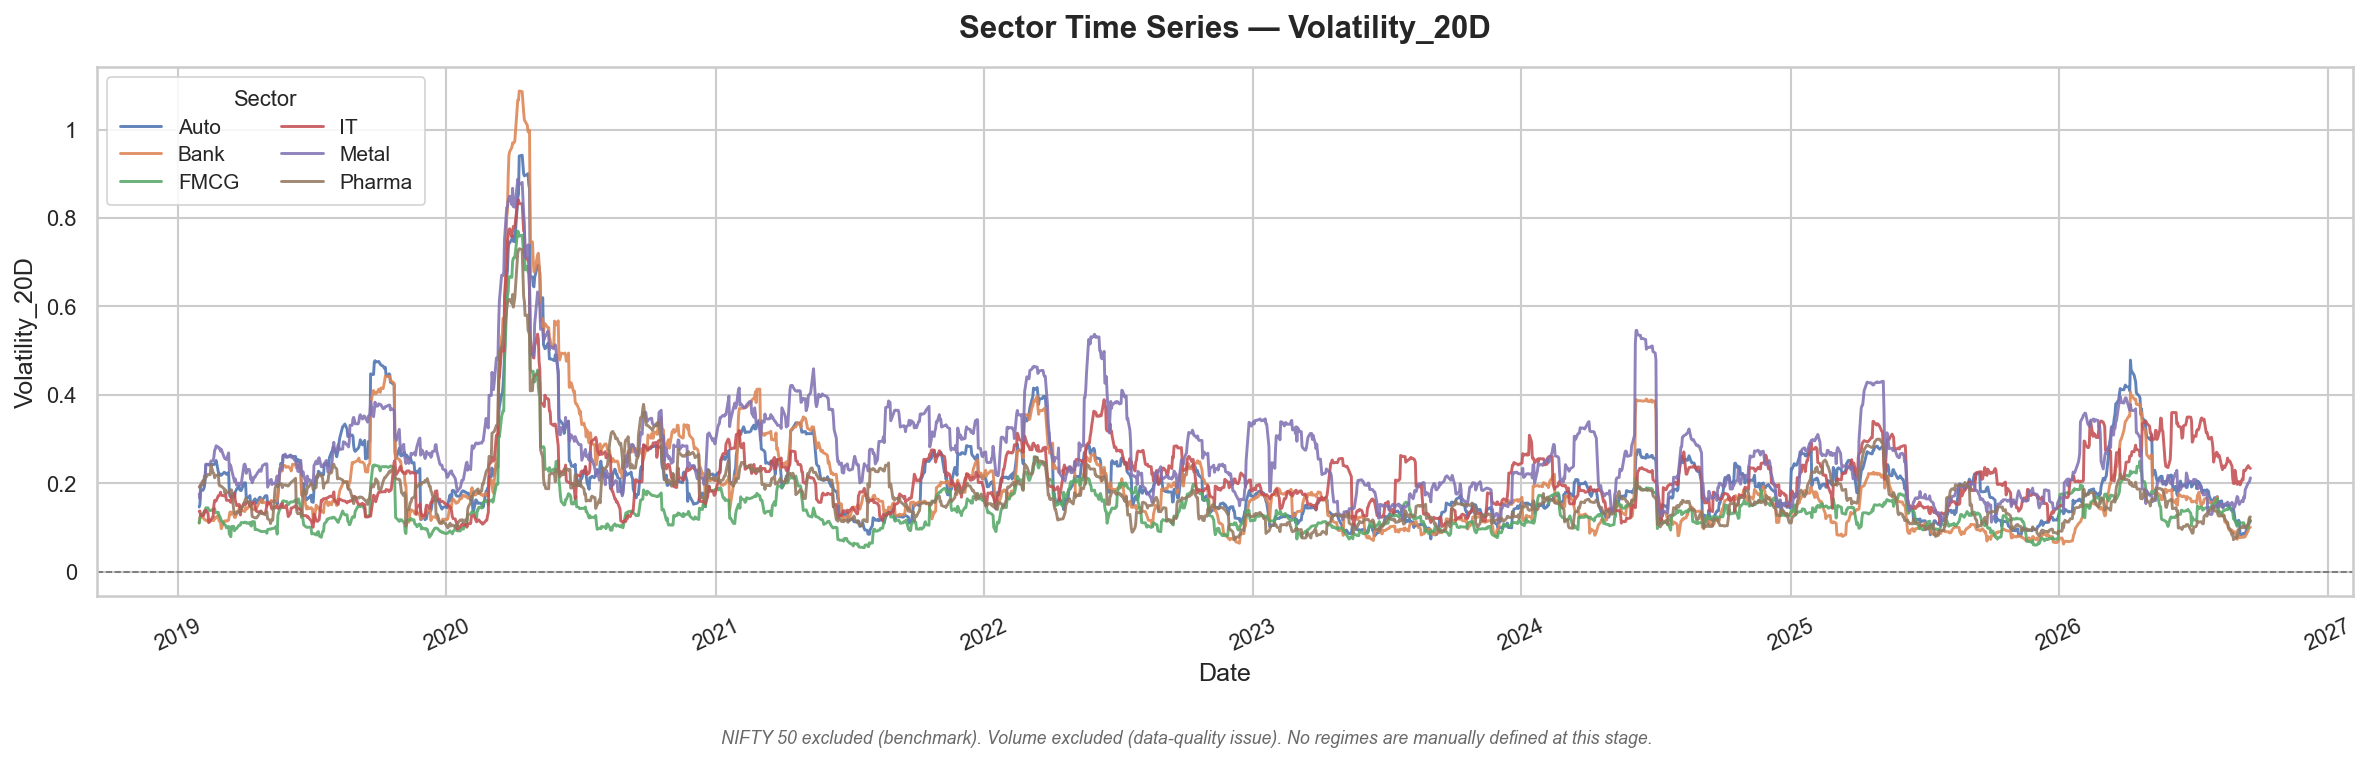

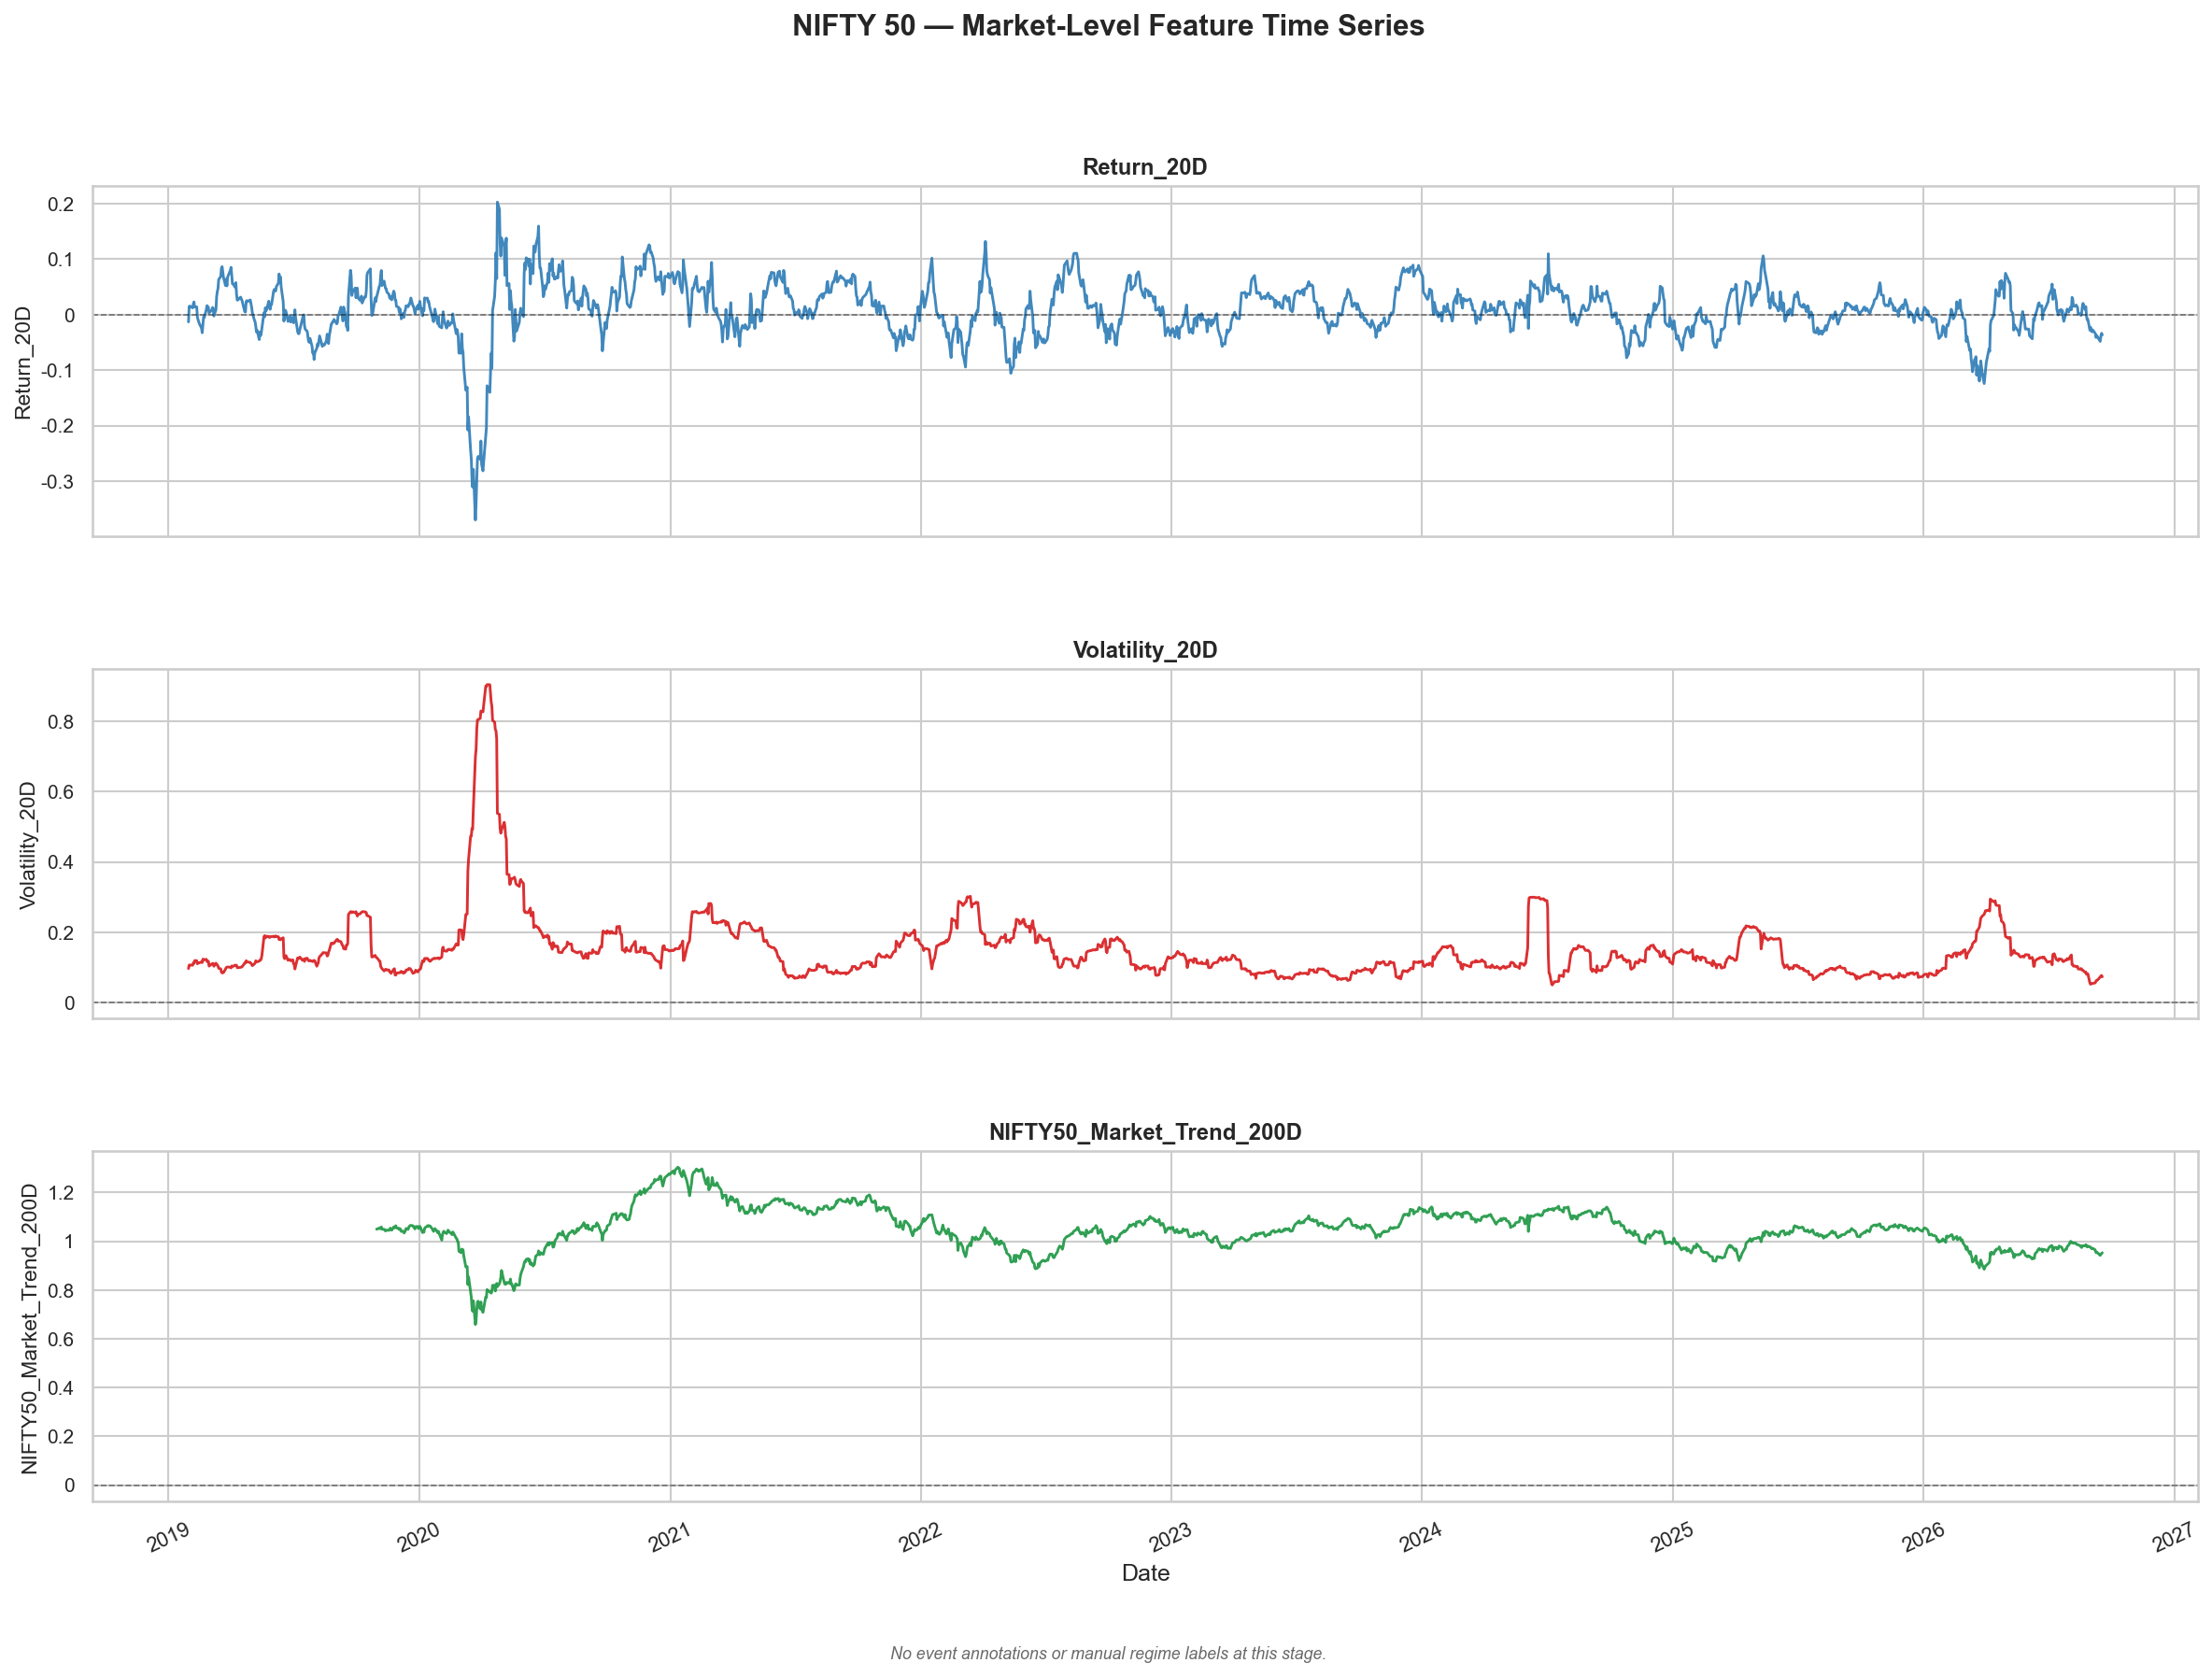

In [15]:
from src.eda import plot_sector_time_series, plot_nifty50_time_series

# Primary sector features for time-series comparison
sector_ts_features = [
    "Return_20D",
    "Relative_Strength_20D",
    "Volatility_20D",
]

# NIFTY 50 market-level features
nifty50_ts_features = [
    "Return_20D",
    "Volatility_20D",
    "NIFTY50_Market_Trend_200D",
]

# One line plot per feature across all six sectors
plot_sector_time_series(datasets, sector_ts_features)

# Stacked subplot for NIFTY 50 market-level view
plot_nifty50_time_series(datasets, nifty50_ts_features)


## infer from 4.5

Market conditions change through time → sectors respond differently → returns, relative strength and volatility change accordingly.

That is exactly the kind of temporal structure that makes regime discovery meaningful.

And remember: we are not calling 2020 a “regime” ourselves. We're only observing that there are clear periods of unusual market behaviour. Later, HMM/GMM will attempt to discover such latent states systematically.

## 4.6 Event-Based Market Behaviour

This section uses the major-event calendar collected for this project to provide contextual interpretation of the market behaviour observed in Section 4.5.

NIFTY 50 `Return_20D` and `Volatility_20D` are plotted as time series with annotated vertical markers for major market events. The annotations allow visual examination of whether unusual market behaviour — such as sharp return movements or elevated volatility — coincides with identifiable macro-economic, policy, or geopolitical events.

Events are used **for interpretation and contextual validation only**. They are not automatically treated as ML features, and no market period is manually labelled as an HMM/GMM regime on the basis of an event. The purpose is to understand whether the engineered features respond to real-world events in a manner consistent with financial-market knowledge.

Annotations are drawn for high-severity events sourced from `data/raw/Events/major_events_2019_2026.csv`. Colour coding distinguishes event categories (pandemic, monetary policy, Indian policy, geopolitical, trade policy, etc.).

Final feature-selection conclusions are deferred to Section 4.7.


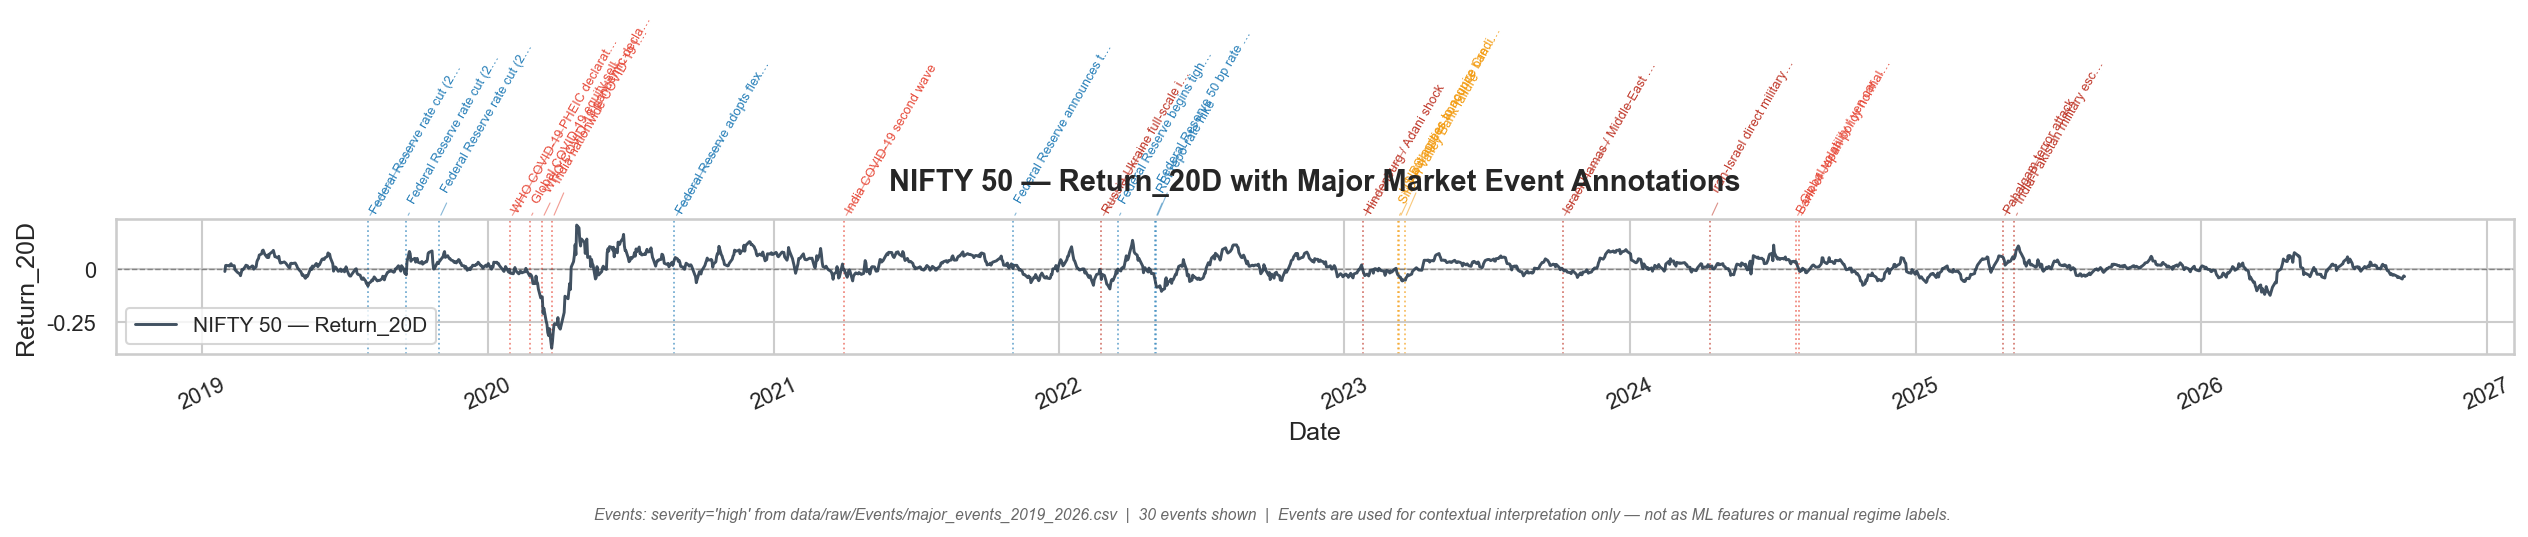

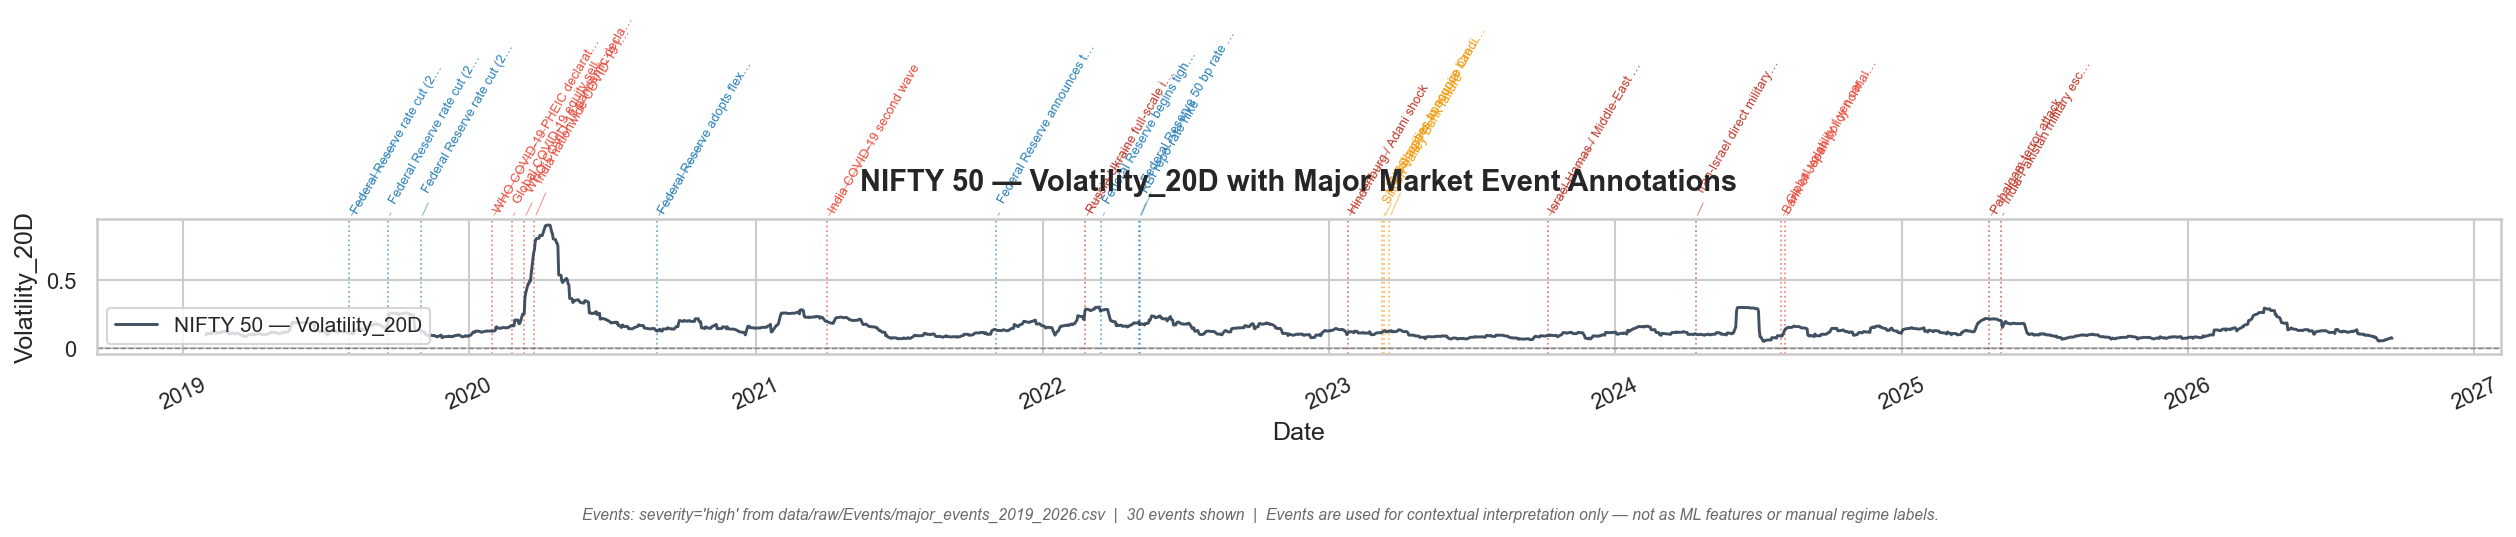

In [20]:
from src.eda import load_event_calendar, plot_event_annotated_market_behaviour

# Load the existing event calendar (DD-MM-YYYY dates parsed automatically)
events = load_event_calendar()

# Annotated time-series for the two primary NIFTY 50 market features
plot_event_annotated_market_behaviour(
    datasets=datasets,
    features=["Return_20D", "Volatility_20D"],
    events=events,
    severity_filter="high",
    max_annotations=30,
)


### 4.6.1 Sector Response Around Major Market-Wide Events

In this section, a carefully selected subset of major, market-wide macro shocks (e.g., pandemic, geopolitical, domestic shock) are examined. The six NIFTY sectors are compared around the exact same event windows (±30 trading days).

**Purpose & Scope:**
* To observe whether the sectors respond homogeneously or divergently (in direction, magnitude, and recovery) to the same broad market stimulus.
* The primary features analyzed are `Return_20D` and `Volatility_20D`, with `Relative_Strength_20D` included to highlight relative outperformance/underperformance versus the broader market.
* **Important:** This is a descriptive evaluation. Events are used strictly for contextual interpretation. No sectors are being ranked as "best" or "worst", and these events are not used as automatic ML features nor to manually define regimes.


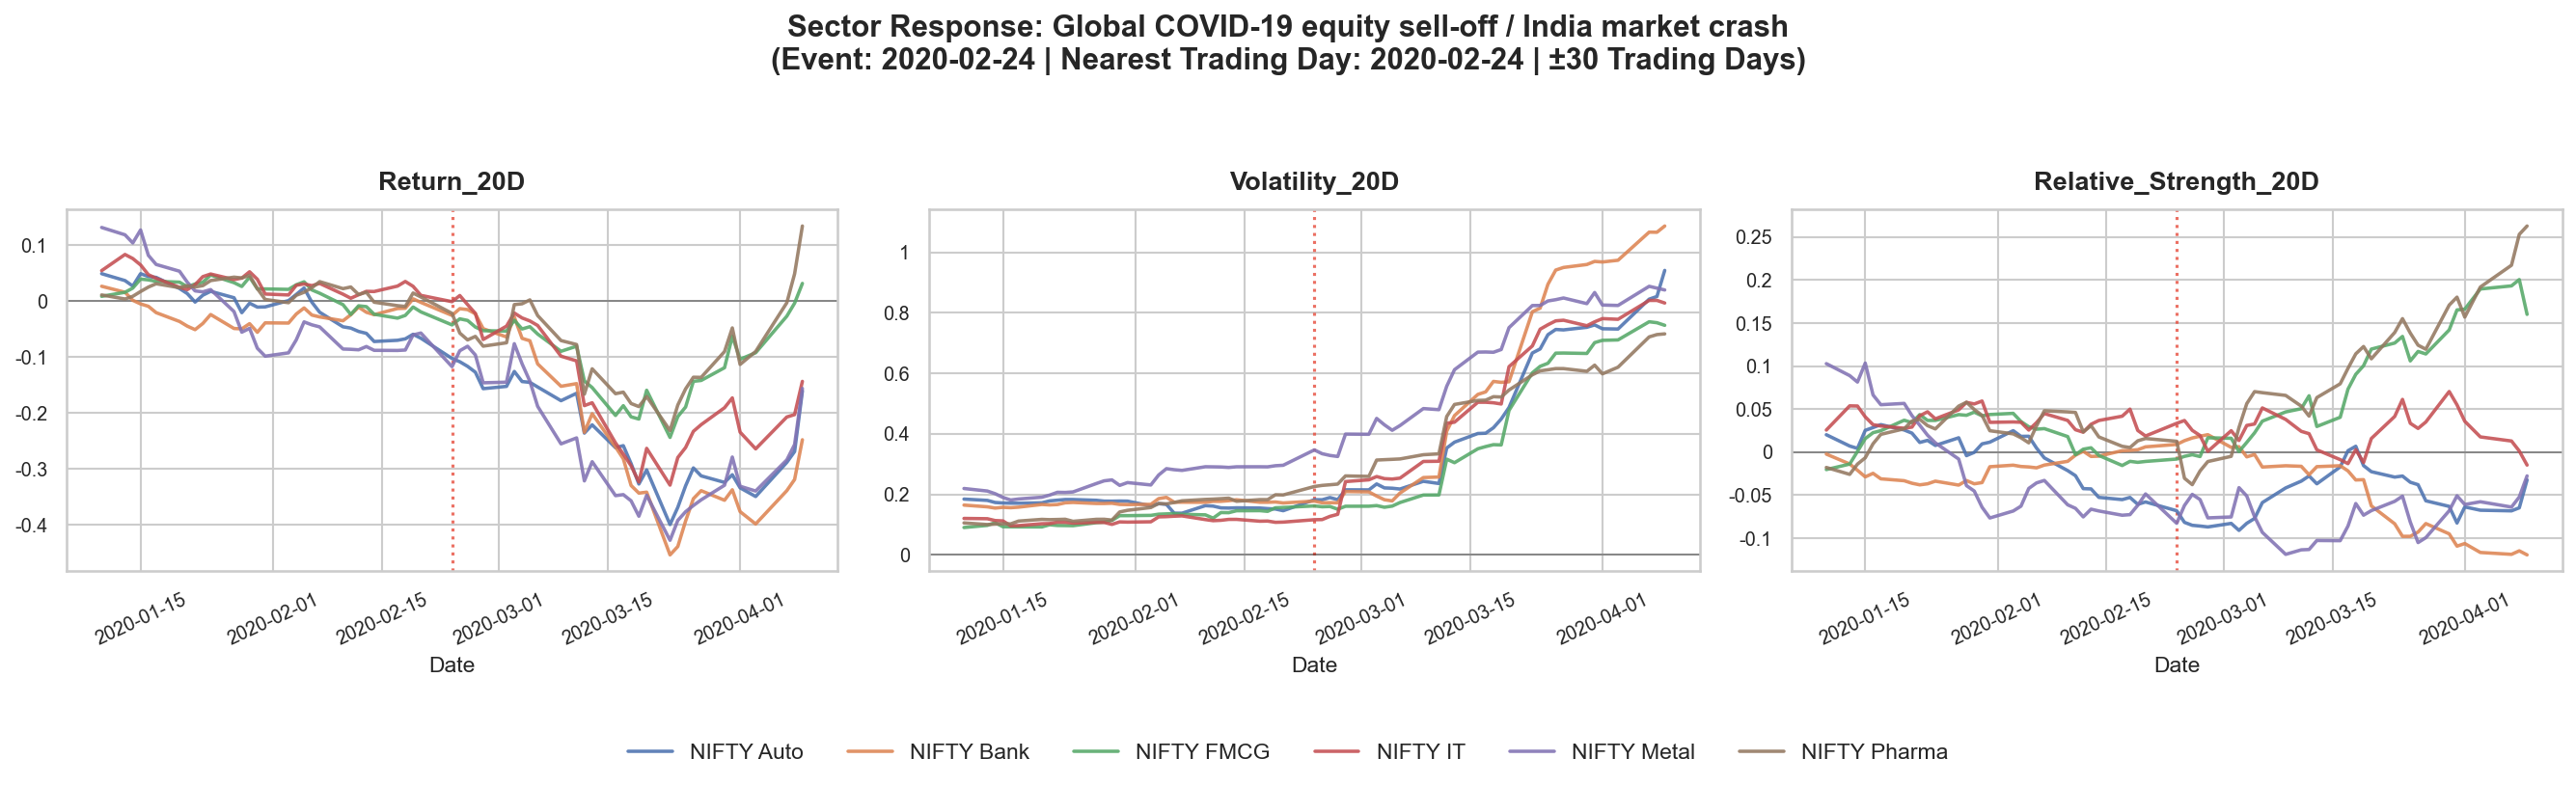

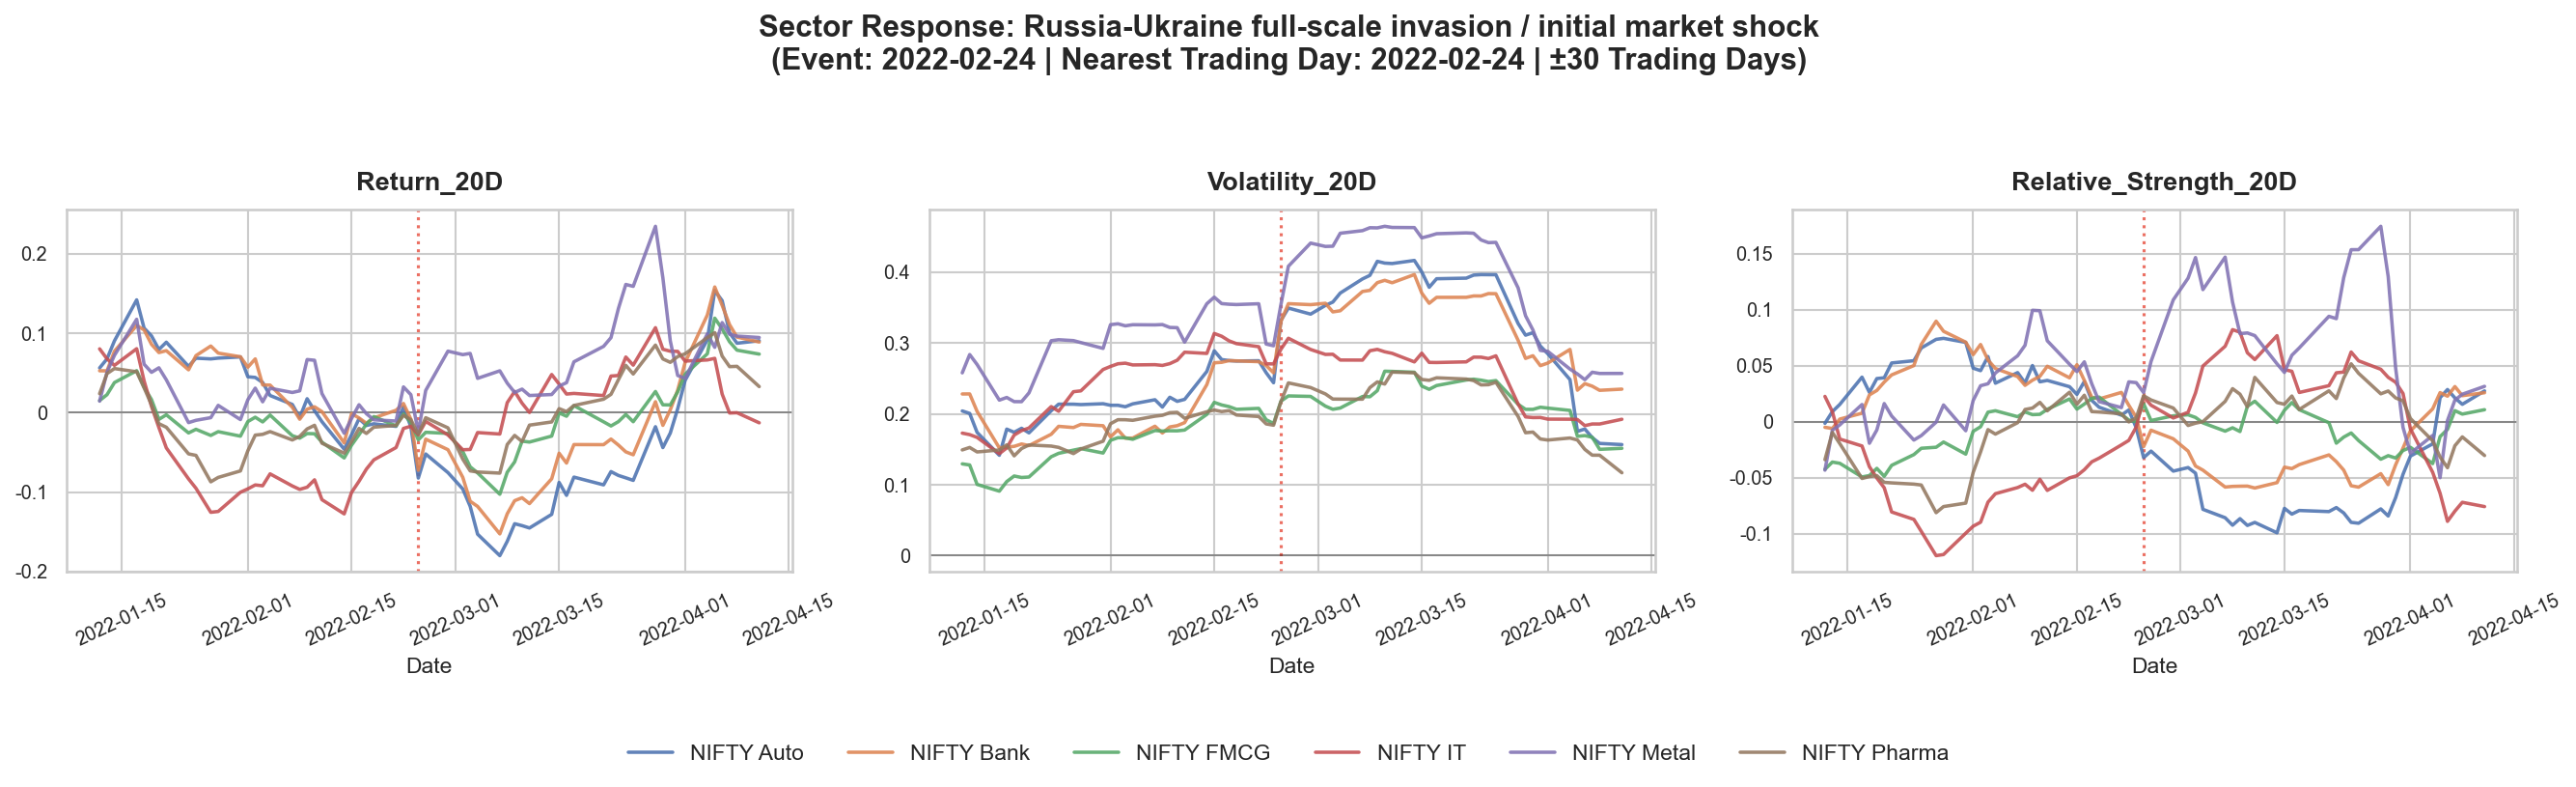

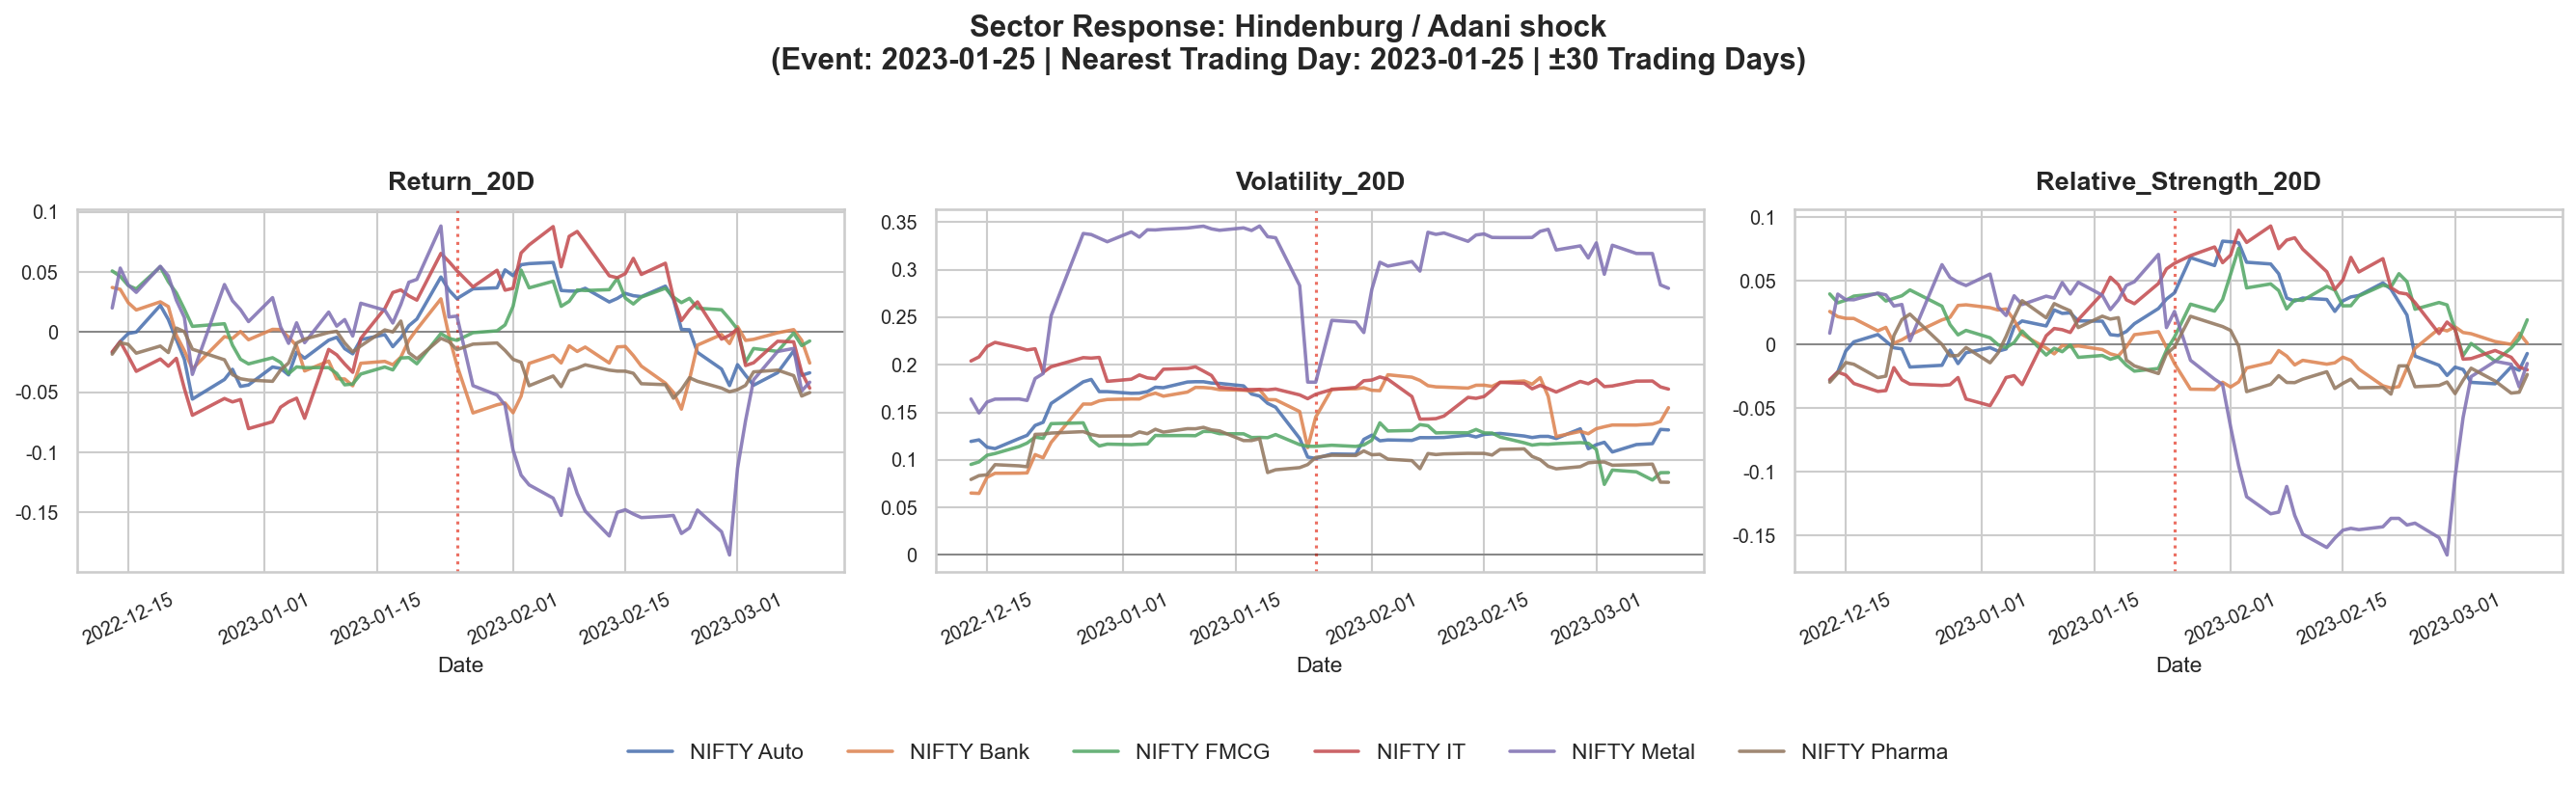

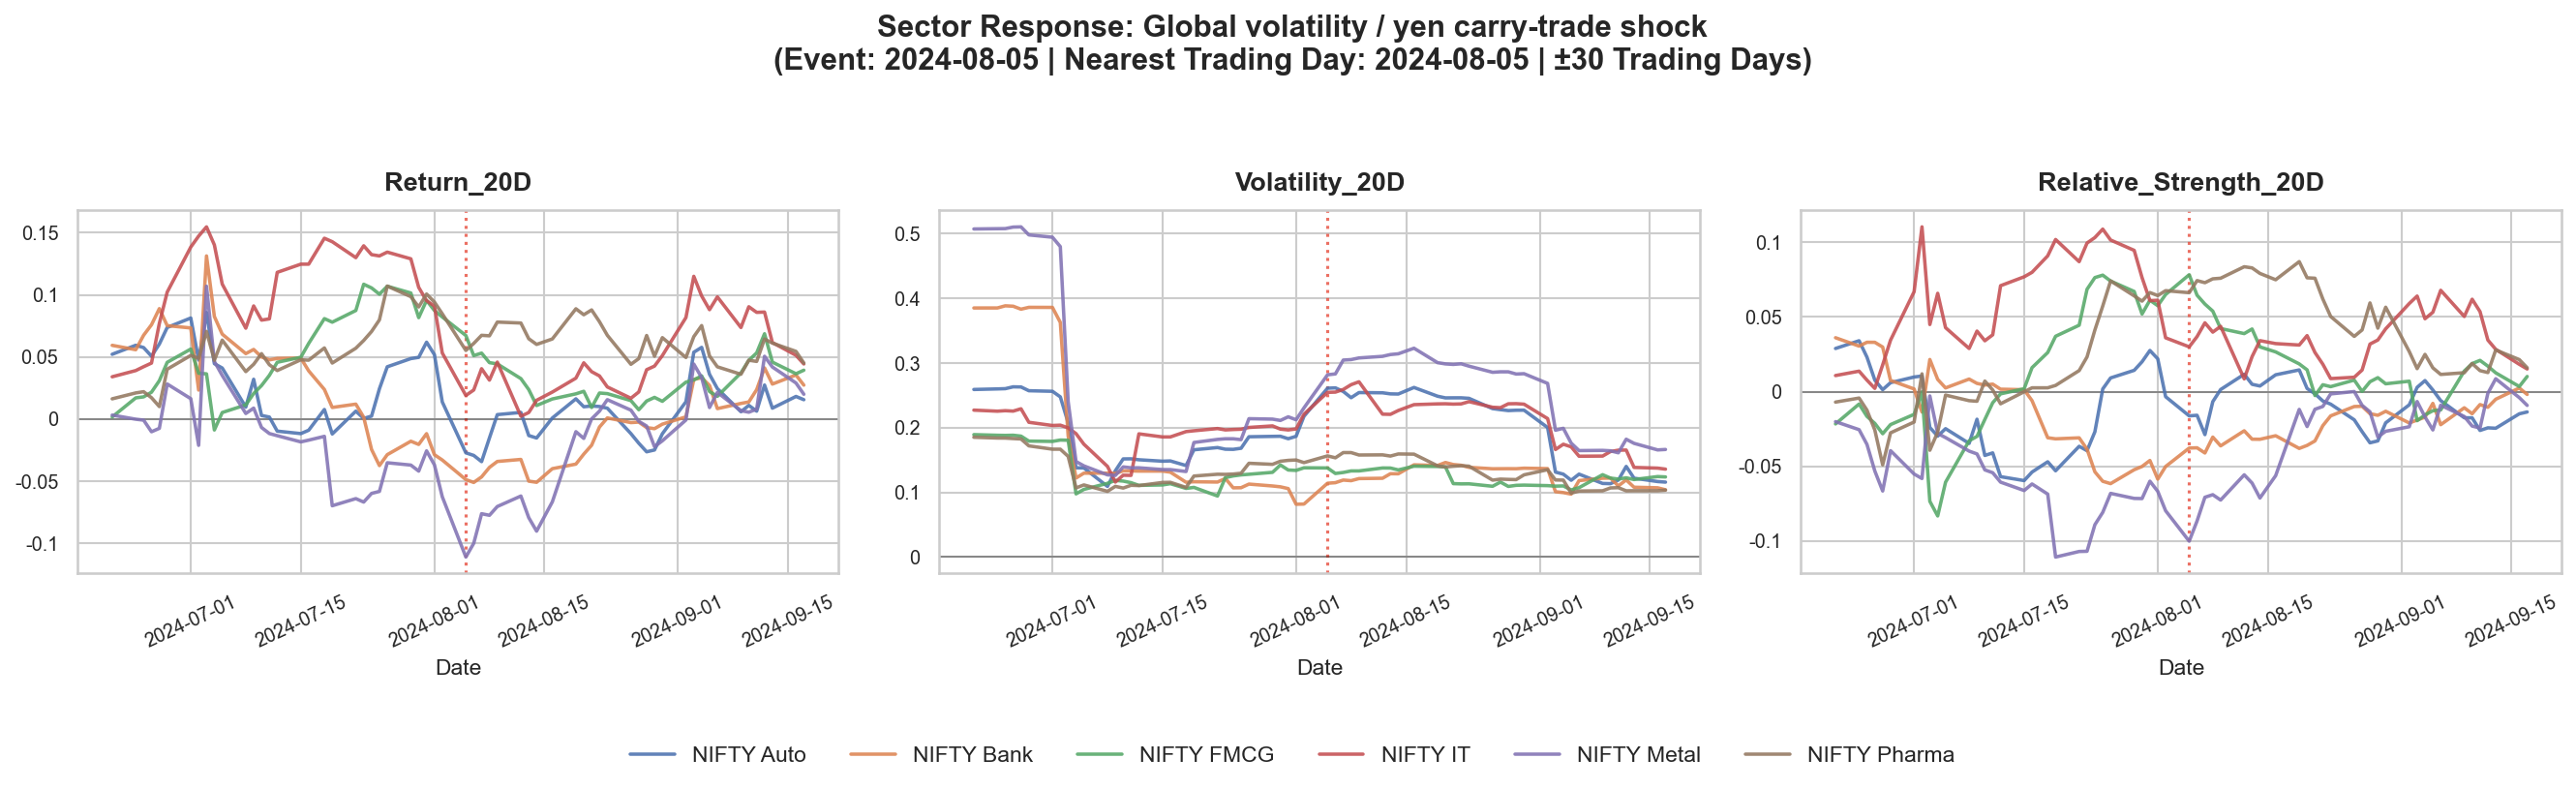

In [21]:
from src.eda import plot_sector_event_response

# Select 4 major broad-market shocks from the existing calendar spanning 2020-2024
# E018: Global COVID-19 equity sell-off (Pandemic)
# E041: Russia-Ukraine invasion initial shock (Geopolitical)
# E064: Hindenburg / Adani shock (Domestic Shock)
# E091: Global volatility / yen carry-trade shock (Global Shock)
major_macro_shocks = ["E018", "E041", "E064", "E091"]

plot_sector_event_response(
    datasets=datasets,
    features=["Return_20D", "Volatility_20D", "Relative_Strength_20D"],
    events=events,
    event_ids=major_macro_shocks,
    window_days=30
)


## infer from 4.6

Major market-wide events are associated with noticeable changes in returns and volatility, while the six sectors can exhibit different magnitudes and patterns of response to the same event. This demonstrates both common market-wide behaviour and sector-specific behaviour over time.

We are NOT going to feed these event labels directly into HMM/GMM just because they appear here.

The event calendar is serving as contextual validation/interpretation.

The model should first discover latent regimes from market/sector behaviour, and then we can ask whether major events help explain or contextualize those regimes.

So, as your mentor:

## 4.7 EDA Findings and Final Feature Selection

The exploratory data analysis was conducted to understand the statistical properties, relationships, temporal behaviour, sector-specific characteristics, and event responses of the engineered features.

The analysis produced the following key findings:

- Return features exhibit asymmetric distributions, with shorter-term returns generally showing stronger negative skewness.
- Volatility features are positively skewed, with long right tails representing periods of elevated market variability and stress.
- Relative-strength features provide information about sector performance relative to the NIFTY 50 benchmark and show sector-specific behaviour.
- NIFTY 50 momentum and market-trend features provide information about market conditions across different time horizons.
- Correlation analysis identified relationships between features, particularly between features calculated over different horizons. However, high correlation was not treated as sufficient evidence for feature removal because different horizons can represent different temporal characteristics of the market.
- Time-series and event-based analysis showed that market conditions change over time and that sectors can respond differently to the same market-wide events.
- Volume was found to have inconsistent reliability across datasets due to zero-volume observations, particularly in NIFTY Bank and NIFTY IT. Therefore, Volume is retained for reference and EDA but excluded from the baseline model feature set.
- No outliers were removed because the identified extreme observations may represent genuine market movements, volatility spikes, or unusual sector behaviour rather than data errors.

### Final Feature Selection

For each of the six sectoral indices, the following features are retained:

- `Return_20D`
- `Return_60D`
- `Relative_Strength_20D`
- `Relative_Strength_60D`
- `Volatility_20D`
- `Volatility_60D`

For the NIFTY 50 benchmark, the following features are retained:

- `Return_20D`
- `Return_60D`
- `NIFTY50_Momentum_20D`
- `NIFTY50_Momentum_60D`
- `NIFTY50_Market_Trend_200D`

Additionally, `VIX_Close` from the aligned India VIX dataset is retained as a market-wide risk indicator.

This results in a baseline feature set of **42 features**:

- 36 sector-level features (6 sectors × 6 features)
- 5 NIFTY 50 market-level features
- 1 India VIX feature

### Features Excluded from the Baseline Model

`Volume` is excluded from the baseline model because its reliability is inconsistent across sector datasets, with substantial zero-volume observations in some indices. However, the original Volume data is preserved and was included in the EDA for analysis.

The event calendar is also not included directly as a model feature. It is used for contextual interpretation and validation of discovered market behaviour.

### Final Conclusion

The EDA indicates that the engineered features capture multiple dimensions of market and sector behaviour, including short-term performance, medium-term performance, benchmark-relative strength, volatility, market momentum, long-term market trend, and market-wide risk.

Both 20-day and 60-day features are retained because they represent different temporal horizons. Although these features can be highly correlated, short-term and medium-term market conditions do not necessarily evolve identically. Therefore, correlation alone is not considered sufficient justification for removing one of the horizons.

The resulting 42-feature set will be carried forward to the normalization stage and subsequently evaluated for unsupervised regime discovery using HMM/GMM models.